In [1]:
"""
Aim: Make figures for manuscript Fig.2
Author: Yike Xie
Date: 15-May-2026 
"""

'\nAim: Make figures for manuscript Fig.2\nAuthor: Yike Xie\nDate: 15-May-2026 \n'

memento and DESeq analyses were done after:
    
1) keeping only basal_ductal and high_enzyme_ductal in ductal cells

2) removing doublets in basal_ductal

In [ ]:
import sys
sys.path.append("..")
import utils

import pandas as pd
import numpy as np
import os

import scanpy as sc
import anndata as ad

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42   # TrueType fonts
rcParams['svg.fonttype'] = 'none'  # For editable text in SVG

# Load data

In [4]:
### only keep protein coding genes
gene_type = pd.read_csv(
    '/home/yike/resources/Human_Sapiens_gene_type.csv', 
    sep=',', index_col='gene_type'
)

protein_coding_genes = gene_type.loc['protein_coding']['gene_name'].tolist()

In [5]:
metadata = pd.read_excel(
    '../../figures/manuscript_figures/tables/Table1_human_donor_information.xlsx',
    sheet_name='Pancreas', index_col=0)

tech_cols = ["snRNA-Seq", "Immunostaining", "Spatial transcriptomics", "Calcium imaging", "Slice-Seq"]
tech_mask = metadata[tech_cols].astype(str).apply(lambda s: s.str.lower().str.strip().eq("yes"))

metadata["Method"] = tech_mask.apply(
    lambda row: ", ".join([col for col, ok in row.items() if ok]),
    axis=1
)

In [18]:
# load data
adata = sc.read_h5ad('../../data/parse_snRNA_annotated_YK_raw.h5ad')
adata = adata[adata.obs['Doublets'] == 'no'].copy()

# remove sample F1 -- 12 years old, the only male donor in ND-Obese
adata = adata[adata.obs['sample'] != 'F1'].copy()

# edit the name of acinar cell subtypes refering to the paper: DOI: 10.1101/2025.10.01.679230
adata.obs['cell_subtype'] = adata.obs['cell_subtype'].astype(str)

mask1 = adata.obs['cell_type'] == 'Acinar'
adata.obs.loc[mask1, 'cell_subtype'] = adata.obs.loc[mask1, 'cell_subtype2']

mask2 = adata.obs['cell_type'] == 'Endothelial'
adata.obs.loc[mask2, 'cell_subtype'] = adata.obs.loc[mask2, 'cell_subtype1']

# Fix cell_type replacement safely
adata.obs['cell_subtype'] = adata.obs['cell_subtype'].astype(str).replace({
    'Signaling_acinar': 'Idling_acinar',
    'High_enzyme_acinar': 'Signaling_acinar',
})

desired_cst_order = [
    'α', 'β', 'γ', 'δ', 'Idling_acinar', 'Intermediate_acinar', 'Signaling_acinar',
    'Basal_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2', 'MUC5B+_ductal',
    'Arterial_ECs', 'Venous_ECs', 'Capillary_ECs', 'Lymphatic_ECs',                   
    'Macrophages', 'Plasmablasts', 'T_cells', 'Mast_cells',
    'Activated_stellates', 'Quiescent_stellates', 'Schwann'
]
adata.obs['cell_subtype'] = adata.obs['cell_subtype'].astype('category')
adata.obs['cell_subtype'] = (
    adata.obs['cell_subtype']
    .cat.set_categories(desired_cst_order, ordered=True)
)

# normalize and logrithmize the data
adata_raw = adata.copy()
utils.normalizedata(adata, log1p=True)

AnnData object with n_obs × n_vars = 56808 × 38560
    obs: 'sample', 'doublet_score', 'Sex', 'BMI', 'T1D', 'Diabetes Duration', 'T2D', 'HbA1c (%)', 'HbA1c', 'Age', 'CIT (hours)', 'Cohort', 'RIN', 'Nuclei isolation', 'group', 'cell_type', 'cell_subtype', 'cell_subtype1', 'cell_subtype2', 'Doublets', 'batch'
    var: 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Doublets_colors', 'cst1_colors', 'log1p'
    obsm: 'X_pca', 'X_umap'

In [19]:
ct_palette = utils.load_ct_palette()
cst_palette = utils.load_cst_palette()

cell_types = adata.obs['cell_type'].cat.categories
cell_subtypes = adata.obs['cell_subtype'].cat.categories

groups = adata.obs['group'].cat.categories
group_colors = {group: sns.color_palette('husl', 5)[i] 
                for i, group in enumerate(['ND-Lean', 'ND-Obese', 'Pre-T2D', 'T1D', 'T2D'])}

In [20]:
cst_ticklabels = {}

for ct in cell_types:
    cst_ticklabels[ct] = ct.replace('_', ' ')

for cst in adata.obs['cell_subtype'].cat.categories:
    if '_' not in cst:
        cst_ticklabels[cst] = cst
    elif 'High_enzyme' in cst:
        cst_ticklabels[cst] = cst.split('_')[0] + ' ' + cst.split('_')[1]
    elif 'Inflam' in cst:
        cst_ticklabels[cst] = cst.split('_')[0] + ' ' + cst.split('_')[2]
    else:
        cst_ticklabels[cst] = cst.split('_')[0]

In [21]:
# cell type and cell subtype dict
unique_combinations = adata.obs[['cell_type', 'cell_subtype']].drop_duplicates()
cst_order = adata.obs['cell_subtype'].cat.categories
unique_combinations = (
    unique_combinations.sort_values(by=['cell_type', 'cell_subtype'], 
                 key=lambda col: col.map({k: i for i, k in enumerate(cst_order)}) 
                 if col.name == 'cell_subtype' else col)
)

ct_cst_dic = (
    unique_combinations
    .groupby('cell_type', observed=True)['cell_subtype']
    .apply(list)
    .to_dict()
)

# Correct way to invert: value items become keys
cst_ct_dic = {subtype: cell_type for cell_type, subtypes in ct_cst_dic.items() for subtype in subtypes}

# group and donor dict
group_donor_dict = (metadata.reset_index()[['group', 'index']].groupby('group', observed=True)['index']
    .apply(list)
    .to_dict())

In [22]:
def pval_to_stars(pval):
    if pval < 0.001:
        return '***'
    elif pval < 0.01:
        return '**'
    elif pval < 0.05:
        return '*'
    else:
        return 'ns'

def break_label(label, max_len=30):
    words = label.split()
    lines = []
    current_line = ""

    for word in words:
        if len(current_line + " " + word) <= max_len:
            if current_line:
                current_line += " " + word
            else:
                current_line = word
        else:
            lines.append(current_line)
            current_line = word

    if current_line:
        lines.append(current_line)

    return '\n'.join(lines)

In [ ]:
import gseapy as gp

def get_pth_res(genes, gene_sets, fig_FDR, n_entities):


    all_results = []
    for gs in gene_sets:
        enr = gp.enrichr(
            gene_list=genes,
            gene_sets=gs,
            organism='Human',
            cutoff=False)
        res = enr.res2d.copy()
        all_results.append(res)

    df = pd.concat(all_results, ignore_index=True)

    df['Pathway identifier'] = df['Term'].str.split('(').str[-1].str[:-1]
    df['#Entities found'] = df['Overlap'].str.split('/').str[0].astype('int')
    df['#Entities total'] = df['Overlap'].str.split('/').str[1].astype('int')

    df_strict = df[
            (df['Adjusted P-value'] < fig_FDR) # < 0.1
            & (df['#Entities found'].astype('int') > n_entities)
        ]

    return df_strict

# Compute and load DEG and pathway analysis

## memento and DESeq results

- memento analysis please refer to `3snRNA-Seq_DEG_analysis_by_memento`
- DESeq analysis please refer to `4snRNA-Seq_DEG_analysis_by_DESeq`

### preprocessing

In [10]:
# add some information to DESeq results

if False:
    data_folder = '../../tables/DESeq/DESeq_results/obese_rF1/'

    ct_cts = {
    'cell_type': [
            'Endocrine', 
            'Acinar', 
            'Ductal', 
            'Endothelial', 
            'Immune', 
            'Stellate',
            'Schwann'
    ],
        'cell_subtype1': [
            'α', 'β', 'δ', 'γ',  
            'Idling_acinar', 'Intermediate_acinar', 'Signaling_acinar', 
            'Basal_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2', 'MUC5B+_ductal', 
            'Arterial_ECs', 'Venous_ECs', 'Capillary_ECs', 'Lymphatic_ECs', 
            'Macrophages', 'Plasmablasts', 'T_cells', # 'Mast_cells', 
            'Activated_stellates', 'Quiescent_stellates', 
#             'Schwann'
        ]
                    }
    ref_group = 'ND-Lean'
    pseudo_sum = '../../tables/DESeq/pseudo_bulk_sum/obese_rF1/'

    for covariate, covariate_name in zip(['by_sex', 'not_by_sex'], ['_by_Sex', '']):
        for ct_obs in ['cell_type', 'cell_subtype1']: # 

            for ct in ct_cts[ct_obs]:
                pseudo_bulk_exp = pd.read_csv(os.path.join(pseudo_sum, f'{ct_obs}_{ct}_pseudo_bulk_sum_counts.tsv'), sep='\t', index_col=0)
                pseudo_bulk_exp_log2cpm = np.log2(pseudo_bulk_exp * 1e6 / pseudo_bulk_exp.sum() + 1)

                for group in ['ND-Obese', ]: # 'Pre-T2D', 'T2D', 'T1D'
                    fn = f'DESeq_group_{ct_obs}_{ct}_{group}_vs_{ref_group}{covariate_name}.tsv'

                    if os.path.exists(os.path.join(data_folder, fn)):
                        result_1d = pd.read_csv(os.path.join(data_folder, fn), sep='\t', index_col=0)
                        # rename
                        result_1d = result_1d.rename(columns={
                                        'log2FoldChange': 'de_log2FC',
                                        'lfcSE': 'de_se',
                                        'stat': 'de_stat',
                                        'pvalue': 'de_pval',
                                        'padj': 'de_pval_adj',})
                        result_1d['-log10(de_pval_adj)'] = - np.log10(result_1d['de_pval_adj'])

                        # add other information
                        ref_donors = list(set(group_donor_dict[ref_group]) & set(pseudo_bulk_exp_log2cpm.columns))
                        group_donors = list(set(group_donor_dict[group]) & set(pseudo_bulk_exp_log2cpm.columns))

                        pseudo_bulk_log2FC = pd.Series((
                            pseudo_bulk_exp_log2cpm[group_donors].mean(axis=1)) - 
                            pseudo_bulk_exp_log2cpm[ref_donors].mean(axis=1),
                            index=adata.var_names)
                        # log2fc of pseudo bulk data
                        result_1d['pseudo_bulk_log2FC'] =  pseudo_bulk_log2FC.loc[result_1d.index].tolist()
                        # expression log2cpm
                        result_1d[f'Exp_{ref_group}'] = pseudo_bulk_exp_log2cpm[ref_donors].mean(axis=1).loc[result_1d.index].to_list()
                        result_1d[f'Exp_{group}'] = pseudo_bulk_exp_log2cpm[group_donors].mean(axis=1).loc[result_1d.index].to_list()
                        # number of donor expressing the gene
                        result_1d[f'N_donor_{ref_group}'] = (pseudo_bulk_exp_log2cpm[ref_donors] > 0).sum(axis=1).loc[result_1d.index].to_list()
                        result_1d[f'N_donor_{group}'] = (pseudo_bulk_exp_log2cpm[group_donors] > 0).sum(axis=1).loc[result_1d.index].to_list()
                        # percentage of donor expressing the gene
                        result_1d[f'Pct_donor_{ref_group}'] = result_1d[f'N_donor_{ref_group}'] / len(ref_donors)
                        result_1d[f'Pct_donor_{group}'] = result_1d[f'N_donor_{group}'] / len(group_donors)

                        # save data to another folder
                        result_1d.to_csv(os.path.join(data_folder + 'full_data/', fn), sep='\t')

                    else:
                        print(f'{ct_obs} {ct} {group} does not exist')

In [11]:
# add some information to memento results
from scipy.sparse import issparse
from statsmodels.stats.multitest import multipletests

if False:
    data_folder = '../../tables/memento/results/obese_rF1/'
    ct_cts = {
        'cell_type': [
            'Endocrine', 
            'Acinar', 
            'Ductal', 
            'Endothelial', 
            'Immune', 
            'Stellate',
            # 'Schwann'
    ],
        'cell_subtype': [
            'α', 'β', 'δ','γ',  
            'Idling_acinar', 'Intermediate_acinar', 'Signaling_acinar', 
            'Basal_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2', 'MUC5B+_ductal', 
            'Arterial_ECs', 'Venous_ECs', 'Capillary_ECs', 'Lymphatic_ECs', 
            'Macrophages', 'Plasmablasts', 'T_cells', # 'Mast_cells', 
            'Activated_stellates', 'Quiescent_stellates', 
            # 'Schwann'
        ]}
    ref_group = 'ND-Lean'
    cell_n_threshold = {'cell_type': 5, 'cell_subtype': 3}
    
    for covariate in ['_by_sex']:
        for ct_obs in ['cell_type', 'cell_subtype']:
            cell_n_df = adata.obs[[ct_obs, 'group', 'sample']].value_counts().to_frame()

            for ct in ct_cts[ct_obs]:
                # samples with enough cells
                valid_samples = cell_n_df.loc[ct]
                samples = valid_samples[
                    valid_samples['count'] >= cell_n_threshold[ct_obs]
                ].index.get_level_values('sample').unique().tolist()

                # subsample the dataset
                ref_tmp = adata[(adata.obs[ct_obs] == ct) & 
                                (adata.obs['group'] == ref_group) &
                                 adata.obs['sample'].isin(samples)
                               ].copy()

                # number of ref donors expresing the gene
                ref_donor_means = {}
                for sample in ref_tmp.obs['sample'].unique():
                    ref_ad = ref_tmp[ref_tmp.obs['sample'] == sample]
                    ref_mean_expr = ref_ad.X.mean(axis=0)
                    if issparse(ref_ad.X):
                        ref_mean_expr = ref_mean_expr.A1 # convert sparse matrix to 1D array
                    ref_donor_means[sample] = ref_mean_expr
                ref_donor_means_df = pd.DataFrame(ref_donor_means, index=ref_tmp.var_names)
                ref_donor_exp_n = (ref_donor_means_df > 0).sum(axis=1)
                ref_donor_exp_pct = ref_donor_exp_n / len(ref_tmp.obs['sample'].unique())

                # average expression in ref donors
                exp_ref = ref_donor_means_df.mean(axis=1)

                for group in ['ND-Obese', 'Pre-T2D', 'T2D',]: #  'T1D'
                    fn = f'{group}_{[ct_obs, ct_obs + '1'][ct_obs == 'cell_subtype']}_{ct}{covariate}.csv' # filename

                    if os.path.exists(os.path.join(data_folder, fn)) == True:

                        # adjust p-values
                        result_1d = pd.read_csv(os.path.join(data_folder, fn), sep=',')
                        result_1d = result_1d.dropna(subset=['de_pval', 'dv_pval'])

                        result_1d['de_pval'] = result_1d['de_pval'].astype(float)
                        result_1d['dv_pval'] = result_1d['dv_pval'].astype(float)

                        de_pval_adj = multipletests(result_1d['de_pval'], alpha=0.05, method='fdr_bh')[1] 
                        dv_pval_adj = multipletests(result_1d['dv_pval'], alpha=0.05, method='fdr_bh')[1]
                        result_1d['de_pval_adj'] = de_pval_adj
                        result_1d['dv_pval_adj'] = dv_pval_adj

                        result_1d['-log10(de_pval_adj)'] = - np.log10(result_1d['de_pval_adj'])
                        result_1d['-log10(dv_pval_adj)'] = - np.log10(result_1d['dv_pval_adj'])

                        # convert log fold change to log2 fold change
                        result_1d['de_log2FC'] = result_1d['de_coef'] / np.log(2)
                        result_1d['dv_log2FC'] = result_1d['dv_coef'] / np.log(2)

                        # subsample the dataset
                        group_tmp = adata[(adata.obs[ct_obs] == ct) & 
                                          (adata.obs['group'] == group) &
                                           adata.obs['sample'].isin(samples)].copy()

                        # number of group donors expresing the gene
                        group_donor_means = {}
                        for sample in group_tmp.obs['sample'].unique():
                            group_ad = group_tmp[group_tmp.obs['sample'] == sample]
                            group_mean_expr = group_ad.X.mean(axis=0)
                            if issparse(group_ad.X):
                                group_mean_expr = group_mean_expr.A1 # convert sparse matrix to 1D array
                            group_donor_means[sample] = group_mean_expr

                        group_donor_means_df = pd.DataFrame(group_donor_means, index=group_tmp.var_names)
                        group_donor_exp_n = (group_donor_means_df > 0).sum(axis=1)
                        group_donor_exp_pct = group_donor_exp_n / len(group_tmp.obs['sample'].unique())

                        # average expression in group donors
                        exp_group = group_donor_means_df.mean(axis=1)

                        # add results to result_1d
                        result_1d[f'Exp_{ref_group}'] = exp_ref.loc[result_1d['gene']].to_list()
                        result_1d[f'Exp_{group}'] = exp_group.loc[result_1d['gene']].to_list()

                        result_1d[f'N_donor_{ref_group}'] = ref_donor_exp_n.loc[result_1d['gene']].to_list()
                        result_1d[f'N_donor_{group}'] = group_donor_exp_n.loc[result_1d['gene']].to_list()

                        result_1d[f'Pct_donor_{ref_group}'] = ref_donor_exp_pct.loc[result_1d['gene']].to_list()
                        result_1d[f'Pct_donor_{group}'] = group_donor_exp_pct.loc[result_1d['gene']].to_list()

                        result_1d.to_csv(os.path.join(data_folder, fn), sep=',')

                    else:
                        print(f'{ct_obs} {ct} {group} does not exist')


### load results

In [ ]:
# load results
def load_deseq_res(path, ct_obs, ct, group, ref_group, covariate):
    fn = f'DESeq_group_{ct_obs}_{ct}_{group}_vs_{ref_group}{covariate}.tsv'
    
    if fn not in os.listdir(path):
        return None
    else:
        df = pd.read_csv(os.path.join(path, fn), sep='\t', index_col=0)

        col_changes = {}
        for col in df.columns:
            if not col.startswith('deseq'):
                col_changes[col] = 'deseq_' + col

        df = df.rename(columns=col_changes)

        return df

def load_mm_res(path, ct_obs, ct, group, covariate):
    fn = f'{group}_{ct_obs}_{ct}{covariate}.csv'
    
    if fn not in os.listdir(path):
        return None
    else:
        df = pd.read_csv(os.path.join(path, fn), sep=',', index_col='gene').dropna()
        df['memento_log2FC'] = df['de_coef'] / np.log(2)

        df['de_pval_adj'] = multipletests(df['de_pval'], alpha=0.05, method='fdr_bh')[1] 
        df['dv_pval_adj'] = multipletests(df['dv_pval'], alpha=0.05, method='fdr_bh')[1]

        col_changes = {}
        for col in df.columns:
            if not col.startswith('memento'):
                col_changes[col] = 'memento_' + col

        df = df.rename(columns=col_changes)

        return df

## load dresults - with sex as covariates
ann_lists = {
    'cell_type': [
        'Acinar', 
        'Endothelial', 
        'Ductal', 
        'Endocrine',
        'Immune',
        'Stellate',
    ],
    'cell_subtype1': [
        'α', 'β', 
        'Idling_acinar', 'Intermediate_acinar', 'Signaling_acinar', 
        'Basal_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2', 'MUC5B+_ductal',
        'Macrophages', 'Plasmablasts', 'T_cells', 'Mast_cells',
        'Arterial_ECs', 'Venous_ECs', 'Capillary_ECs', 'Lymphatic_ECs',
        'Activated_stellates', 'Quiescent_stellates', 
    ]  
}

methods = {
    'DESeq': '_by_Sex',
    'memento': '_by_sex'  
}

ref_group = 'ND-Lean'
groups = ['ND-Obese', 'Pre-T2D', 'T2D']

deseq_path = '../../tables/DESeq/DESeq_results/obese_rF1/full_data'
memento_path = '../../tables/memento/results/obese_rF1/'

DEG_res = {}

for method, covariate in methods.items():
    for group in groups:
        for ct_obs, cts in ann_lists.items():
            for ct in cts:
                DEG_res[(method, covariate, group, ct)] = load_deseq_res(deseq_path, ct_obs, ct, group, ref_group, covariate) if method == 'DESeq' else load_mm_res(memento_path, ct_obs, ct, group, covariate)

### DESeq vs memento (in supplementary figure)

In [ ]:
# example of getting DEGs

ct_obs = 'cell_type'
ref_group = 'ND-Lean'
ct = 'Acinar'
memento_log2FC = 1
deseq_de_log2FC = 1
memento_de_pval_adj = 0.05

compare_dfs = {}
for group in ['ND-Obese', 'Pre-T2D', 'T2D']:
    deseq_df = DEG_res[('DESeq', '_by_Sex', group, ct)]
    memento_df = DEG_res[('memento', '_by_sex', group, ct)]
    # merge DESeq and memento results
    common_genes = list(set(memento_df.index) & set(deseq_df.index))
    compare_df = pd.concat([memento_df.loc[common_genes], deseq_df.loc[common_genes]], axis=1)

    compare_df['Group'] = 'ns'
    if group != 'Pre-T2D':
        # for groups other than Pre-T2D, get DEGs based on both memento and DESeq
        compare_df.loc[
            (((compare_df['memento_log2FC'] > memento_log2FC) 
             & (compare_df['deseq_de_log2FC'] > 0))
            | 
            ((compare_df['deseq_de_log2FC'] > deseq_de_log2FC)
            & (compare_df['memento_log2FC'] > 0))) 
            & (compare_df['memento_de_pval_adj'] < memento_de_pval_adj),
            'Group'] = 'Up'

        compare_df.loc[
            (((compare_df['memento_log2FC'] < - memento_log2FC) 
             & (compare_df['deseq_de_log2FC'] < 0))
            | 
            ((compare_df['deseq_de_log2FC'] < - deseq_de_log2FC)
            & (compare_df['memento_log2FC'] < 0)))
            & (compare_df['memento_de_pval_adj'] < memento_de_pval_adj),
            'Group'] = 'Down'
        compare_dfs[group] = compare_df
    else:
        # for Pre-T2D, get DEGs based on DESeq
        compare_df.loc[
            (compare_df['deseq_de_log2FC'] > deseq_de_log2FC)
            & (compare_df['memento_log2FC'] > memento_log2FC)
            & (compare_df['memento_de_pval_adj'] < memento_de_pval_adj),
            'Group'] = 'Up'

        compare_df.loc[ 
            (compare_df['deseq_de_log2FC'] < - deseq_de_log2FC)
            & (compare_df['memento_log2FC'] < - memento_log2FC)
            & (compare_df['memento_de_pval_adj'] < memento_de_pval_adj),
            'Group'] = 'Down'
        compare_dfs[group] = compare_df
        
# plotting
fig, axs = plt.subplots(1, 2, figsize=[6, 3], sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.01, wspace=0.05)

for group, ax in zip(['ND-Obese', 'Pre-T2D'], axs):
    sns.scatterplot(
        data=compare_dfs[group], 
        x='memento_log2FC', 
        y='deseq_de_log2FC', 
        ax=ax, alpha=0.5, 
        hue='Group')
    ax.set_title(f'{group} vs {ref_group}')

    for i in [- memento_log2FC, 0, memento_log2FC]:
        ax.axvline(i, c='gray', ls='--', zorder=0)

    for i in [- deseq_de_log2FC, 0, deseq_de_log2FC]:
        ax.axhline(i, c='gray', ls='--', zorder=0)

    ax.set_xlim(-4.1, 4.1)
    ax.set_ylim(-4.1, 4.1)
    
    ax.set_xlabel(r'DESeq log$_2$FC')
    ax.set_ylabel(r'memento log$_2$FC')

axs[0].legend().remove()
axs[1].legend(bbox_to_anchor=[1, 1], title='Group', loc='upper left')

# plt.text(-6, 5, ct, fontsize=12)
fig.savefig(
    os.path.join('../figures/pathway_analysis/obese_wV2', 'DEG_selection_DESeq_memento.pdf'),
    dpi=300, bbox_inches='tight'
)
fig.savefig(
    os.path.join('../figures/pathway_analysis/obese_wV2', 'DEG_selection_DESeq_memento.png'),
    dpi=300, bbox_inches='tight'
)

## Pathway analysis & DEG numbers

In [6]:
res_path = '../../tables/pathway_analysis/obese_rF1/results/'
fig_path = '../../figures/pathway_analysis/obese_rF1/results/'

os.makedirs(res_path, exist_ok=True)
os.makedirs(fig_path, exist_ok=True)

In [ ]:
# get pathways and the number of DEGs
from itertools import chain
import gseapy as gp

if False:
    memento_log2FC = 1
    deseq_de_log2FC = 1
    memento_de_pval_adj = 0.05
    fig_FDR = 0.1
    n_entities = 1
    gene_sets = ['GO_Biological_Process_2023', 'Reactome_Pathways_2024']

    # save pathway number information
    pth_numbers = {}
    DEG_numbers = {}
    ref_group = 'ND-Lean'
    groups = ['ND-Obese', 'Pre-T2D', 'T2D'] # 'Pre-T2D', 'ND-Obese', 
    for group in groups:
        for ct in list(chain.from_iterable(ann_lists.values())):
            deseq_df = DEG_res[('DESeq', '_by_Sex', group, ct)]
            memento_df = DEG_res[('memento', '_by_sex', group, ct)]
            
            if deseq_df is None or memento_df is None: # avoid cell subtypes that couldn't get DEGs
                DEG_numbers[(ct, group, 'Up')] = 0
                DEG_numbers[(ct, group, 'Down')] = 0
                
                for DEG_type in ['Up', 'Down']:
                    pth_numbers[('GO' , ct_obs, ct, group, DEG_type)] = 0 
                    pth_numbers[('Reactome' , ct_obs, ct, group, DEG_type)] = 0
            else:
                # merge DESeq and memento results
                common_genes = list(set(memento_df.index) & set(deseq_df.index))
                compare_df = pd.concat([memento_df.loc[common_genes], deseq_df.loc[common_genes]], axis=1)

                if group != 'Pre-T2D':
                    # for groups other than Pre-T2D, get DEGs based on both memento and DESeq
                    up_df = compare_df[
                        (((compare_df['memento_log2FC'] > memento_log2FC) 
                         & (compare_df['deseq_de_log2FC'] > 0))
                        | 
                        ((compare_df['deseq_de_log2FC'] > deseq_de_log2FC)
                        & (compare_df['memento_log2FC'] > 0))) 
                        & (compare_df['memento_de_pval_adj'] < memento_de_pval_adj)
                    ]

                    down_df = compare_df[
                        (((compare_df['memento_log2FC'] < - memento_log2FC) 
                         & (compare_df['deseq_de_log2FC'] < 0))
                        | 
                        ((compare_df['deseq_de_log2FC'] < - deseq_de_log2FC)
                        & (compare_df['memento_log2FC'] < 0)))
                        & (compare_df['memento_de_pval_adj'] < memento_de_pval_adj)
                    ]
                else:
                    # for Pre-T2D, get DEGs based on DESeq
                    up_df = compare_df[
                        (compare_df['deseq_de_log2FC'] > deseq_de_log2FC)
                        & (compare_df['memento_log2FC'] > memento_log2FC)
                        & (compare_df['memento_de_pval_adj'] < memento_de_pval_adj)
                    ]

                    down_df = compare_df[ 
                        (compare_df['deseq_de_log2FC'] < - deseq_de_log2FC)
                        & (compare_df['memento_log2FC'] < - memento_log2FC)
                        & (compare_df['memento_de_pval_adj'] < memento_de_pval_adj)
                    ]
                # save DEG numbers
                DEG_numbers[(ct, group, 'Up')] = up_df.shape[0]
                DEG_numbers[(ct, group, 'Down')] = - down_df.shape[0]

                for genes, DEG_type in zip(
                    [up_df.index.tolist(), down_df.index.tolist()], 
                    ['Up', 'Down']
                ):
                    # reactome pathwat analysis
                    res_fn = f'{ct}_{DEG_type}_{group}_vs_{ref_group}.tsv'
                    all_results = []
                    for gs in gene_sets:
                        enr = gp.enrichr(
                            gene_list=genes,
                            gene_sets=gs,
                            organism='Human',
                            cutoff=False)
                        res = enr.res2d.copy()
                        all_results.append(res)
                    df = pd.concat(all_results, ignore_index=True)

                    df['Pathway identifier'] = df['Term'].str.split('(').str[-1].str[:-1]
                    df['#Entities found'] = df['Overlap'].str.split('/').str[0].astype('int')
                    df['#Entities total'] = df['Overlap'].str.split('/').str[1].astype('int')

                    df_strict = df[
                            (df['Adjusted P-value'] < fig_FDR) # < 0.1
                            & (df['#Entities found'].astype('int') > n_entities)
                        ]

                    # only save significant pathway analysis results
                    df_strict.to_csv(os.path.join(f"{res_path}", res_fn), sep='\t', index=False)

                    if df_strict.shape[0] == 0:
                        print(f'No {DEG_type}regulated pathways in {ct} ({group} vs {ref_group})')
                        pth_numbers[('GO' , ct_obs, ct, group, DEG_type)] = 0
                        pth_numbers[('Reactome' , ct_obs, ct, group, DEG_type)] = 0
                        continue
                    else:
                        # plot pathways with low FDR and more than 1 genes
                        title=f'{DEG_type}regulated pathways in {ct.replace('_', ' ')}\n[{group} vs {ref_group}]'
                        fig_fn = f'{ct}_{DEG_type}_{group}_vs_{ref_group}.png'

                        # save pathway numbers
                        go_df = df_strict[df_strict['Gene_set'] == 'GO_Biological_Process_2023']
                        pth_numbers[('GO' , ct, group, DEG_type)] = go_df.shape[0] if DEG_type == 'Up' else - go_df.shape[0]
                        re_df = df_strict[df_strict['Gene_set'] == 'Reactome_Pathways_2024']
                        pth_numbers[('Reactome' , ct, group, DEG_type)] = re_df.shape[0] if DEG_type == 'Up' else - re_df.shape[0]

                        # plot the significant pathways by dotplot
                        if df_strict.shape[0] == 0:
                            continue
                        else:
                            fig, ax = plt.subplots()
                            gp.dotplot(
                                df_strict, 
                                column='Adjusted P-value', 
                                x='Gene_set',
                                cutoff=fig_FDR, size=10,
                                xticklabels_rot=45,
                                show_ring=True,
                                #top_term=10,
                                marker='o',
                                title=title, ax=ax)
                            fig.savefig(os.path.join(f"{fig_path}", fig_fn), bbox_inches='tight', dpi=300)    

    # save data
    pth_numbers = pd.DataFrame.from_dict(pth_numbers, orient='index')
    pth_numbers.columns = ['#pathway']
    pth_numbers.index = pd.MultiIndex.from_tuples(pth_numbers.index, names=['method', 'cell_type', 'group', 'type'])
    pth_numbers = pth_numbers.reset_index()
    pth_numbers.to_csv(os.path.join(res_path, f'pathway_numbers_FDR{fig_FDR}.tsv'), sep='\t', index=False)   

    DEG_numbers = pd.DataFrame.from_dict(DEG_numbers, orient='index')
    DEG_numbers.columns = ['#DEG']
    DEG_numbers.index = pd.MultiIndex.from_tuples(DEG_numbers.index, names=['cell_type', 'group', 'type'])
    DEG_numbers = DEG_numbers.reset_index()
    DEG_numbers.to_csv(f'../../figures/manuscript_figures/obese_rF1/DEG_numbers_FDR{fig_FDR}.tsv', sep='\t', index=False)

#  The number of DEGs

In [ ]:
# DEG numbers and pathway numbers 
DEG_numbers = pd.read_csv(
    f'../../figures/manuscript_figures/obese_rF1/DEG_numbers_FDR0.1.tsv',
    sep='\t')

# removing F1 only impacts ND-Obese, so I combine the other conditions from revious data
DEG_numbers_org = pd.read_csv(
    '../../tables/pathway_analysis/obese_wV2/results/DEG_numbers_FDR0.1.tsv',
    sep='\t') 

DEG_numbers = pd.concat([
        DEG_numbers[DEG_numbers['group'] == 'ND-Obese'],
        DEG_numbers_org[DEG_numbers_org['group'] != 'ND-Obese']
        ])

In [ ]:
def plot_number_by_group(DEG_numbers, cts, lim, hue_order, palette, **krwargs):
    up_DEG_n = DEG_numbers[
        DEG_numbers['cell_type'].isin(cts)
        & (DEG_numbers['type'] == 'Up')
    ]
    up_DEG_n['cell_type'] = up_DEG_n['cell_type'].astype('category')
    up_DEG_n['cell_type'] = up_DEG_n['cell_type'].cat.reorder_categories(cts)

    down_DEG_n = DEG_numbers[
        DEG_numbers['cell_type'].isin(cts)
        & (DEG_numbers['type'] == 'Down')
    ]
    down_DEG_n['cell_type'] = down_DEG_n['cell_type'].astype('category')
    down_DEG_n['cell_type'] = down_DEG_n['cell_type'].cat.reorder_categories(cts)

    fig, ax = plt.subplots(**krwargs)
    trans = ax.get_xaxis_transform()
    
    sns.barplot(
        up_DEG_n, 
        x='#DEG', y='cell_type', 
        hue='group', 
        hue_order=hue_order,
        palette=palette, 
        alpha=1, ax=ax)

    sns.barplot(
        down_DEG_n, 
        x='#DEG', 
        y='cell_type', 
        hue='group', 
        hue_order=hue_order,
        palette=palette, 
        alpha=0.5, ax=ax, legend=False)

    handles, labels= ax.get_legend_handles_labels()
    legend1 = ax.legend(
        bbox_to_anchor=[1, 1], 
        title='Group', 
        labels=labels, 
        handles=handles,
        handletextpad=0.5,             # space between bar and text
        borderpad=0.6,)

    ax.axvline(0, c='k')

    ax.set_xlim([-lim, lim])
    for i in [-100, 100]:
        ax.axvline(i, c='k', ls='--', zorder=-3)

    ax.set_ylabel(None)
    
    for DEG_type in ['Up', 'Down']:
        ax.annotate(DEG_type, xy=(lim * [-0.5, 0.5][DEG_type == 'Up'], -0.12), 
                            xycoords=trans, ha='center', va='top')
        ax.plot([lim * [-0.95, 0.95][DEG_type == 'Up'], lim * [-0.1, 0.1][DEG_type == 'Up']], 
                        [-0.1, -0.1], 
                        color='k', transform=trans, clip_on=False)
        
    ax.set_xlabel(None)
    ax.annotate('#DEGs', xy=(.5, -0.15), va='center', ha='center', xycoords=trans)
    
    yticks = ax.get_yticks()
    if '_' in ''.join(cts):
        trans_y = ax.get_yaxis_transform()
        
        annotation_order = pd.Series(cts).map(lambda x: cst_ct_dic[x]).unique()
        annotations = pd.Series(cts).map(
            lambda x: cst_ct_dic[x]
        ).value_counts().loc[annotation_order].to_dict()
        y = 0
        for key, value in annotations.items():
            ax.annotate(key, xy=(-0.5, y + value/2 - 0.5), 
                        xycoords=trans_y, 
                        ha='right', va='center')
            ax.plot([-0.48, -0.48], 
                    [y - 0.2, y + value - 0.8], 
                    color='k', transform=trans_y, clip_on=False)
            y += value
            yticklabels = [cst_ticklabels[label.get_text()] for label in ax.get_yticklabels()]
            
    else:
        yticklabels = [label.get_text().replace('_', ' ') for label in ax.get_yticklabels()]
    
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(yticklabels, ha='right')

    return {'fig': fig, 'ax': ax}

/tmp/ipykernel_2407824/3764031174.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  up_DEG_n['cell_type'] = up_DEG_n['cell_type'].astype('category')
/tmp/ipykernel_2407824/3764031174.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  up_DEG_n['cell_type'] = up_DEG_n['cell_type'].cat.reorder_categories(cts)
/tmp/ipykernel_2407824/3764031174.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cav

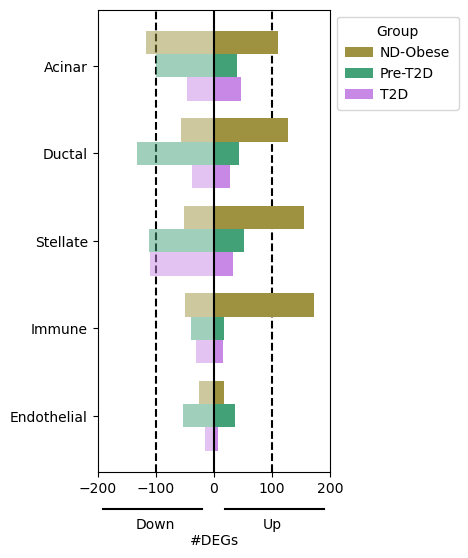

In [ ]:
cts = ['Acinar', 'Ductal', 'Stellate', 'Immune', 'Endothelial']
hue_order=['ND-Obese', 'Pre-T2D', 'T2D']
palette=[group_colors[group] for group in ['ND-Obese', 'Pre-T2D', 'T2D']]

fig = plot_number_by_group(DEG_numbers, cts, 200, hue_order=hue_order, palette=palette, figsize=[3, 6])['fig']

fig.savefig(
    os.path.join('../../figures/manuscript_figures/obese_rF1/', 'DEG_numbers_by_group.png'), 
    dpi=300, bbox_inches='tight'
)
fig.savefig(
    os.path.join('../../figures/manuscript_figures/obese_rF1/', 'DEG_numbers_by_group.pdf'), 
    dpi=300, bbox_inches='tight'
)

# Acinar genes [Obese and T2D] 

In [13]:
ct_obs = 'cell_type'
ct = 'Acinar'
memento_log2FC = 1
deseq_de_log2FC = 1
memento_de_pval_adj = 0.05

compare_dfs = {}
for group in ['ND-Obese', 'Pre-T2D', 'T2D']:
    deseq_df = DEG_res[('DESeq', '_by_Sex', group, ct)]
    memento_df = DEG_res[('memento', '_by_sex', group, ct)]
    # merge DESeq and memento results
    common_genes = list(set(memento_df.index) & set(deseq_df.index))
    compare_df = pd.concat([memento_df.loc[common_genes], deseq_df.loc[common_genes]], axis=1)

    compare_df['Group'] = 'ns'
    if group != 'Pre-T2D':
        # for groups other than Pre-T2D, get DEGs based on both memento and DESeq
        compare_df.loc[
            (((compare_df['memento_log2FC'] > memento_log2FC) 
             & (compare_df['deseq_de_log2FC'] > 0))
            | 
            ((compare_df['deseq_de_log2FC'] > deseq_de_log2FC)
            & (compare_df['memento_log2FC'] > 0))) 
            & (compare_df['memento_de_pval_adj'] < memento_de_pval_adj),
            'Group'] = 'Up'

        compare_df.loc[
            (((compare_df['memento_log2FC'] < - memento_log2FC) 
             & (compare_df['deseq_de_log2FC'] < 0))
            | 
            ((compare_df['deseq_de_log2FC'] < - deseq_de_log2FC)
            & (compare_df['memento_log2FC'] < 0)))
            & (compare_df['memento_de_pval_adj'] < memento_de_pval_adj),
            'Group'] = 'Down'
        compare_dfs[group] = compare_df
    else:
        # for Pre-T2D, get DEGs based on DESeq
        compare_df.loc[
            (compare_df['deseq_de_log2FC'] > deseq_de_log2FC)
            & (compare_df['memento_log2FC'] > memento_log2FC)
            & (compare_df['memento_de_pval_adj'] < memento_de_pval_adj),
            'Group'] = 'Up'

        compare_df.loc[ 
            (compare_df['deseq_de_log2FC'] < - deseq_de_log2FC)
            & (compare_df['memento_log2FC'] < - memento_log2FC)
            & (compare_df['memento_de_pval_adj'] < memento_de_pval_adj),
            'Group'] = 'Down'
        compare_dfs[group] = compare_df

# get family genes
sig_genes = {
    group: compare_dfs[group][compare_dfs[group]['Group'] != 'ns'].index.tolist()
    for group in ['ND-Obese', 'Pre-T2D', 'T2D']
}

up_sig_genes = {
    group: compare_dfs[group][compare_dfs[group]['Group'] == 'Up'].index.tolist()
    for group in ['ND-Obese', 'Pre-T2D', 'T2D']
}

down_sig_genes = {
    group: compare_dfs[group][compare_dfs[group]['Group'] == 'Down'].index.tolist()
    for group in ['ND-Obese', 'Pre-T2D', 'T2D']
}

all_genes = list(set(gene for genes in sig_genes.values() for gene in genes)) # all DEGs from each group vs lean

pseudo_sum = '../../tables/DESeq/pseudo_bulk_sum/obese_rF1/'
# the median pseudo-bulk expression of these DEGs in every group
pseu_bu_median = pd.DataFrame(index=all_genes, columns=['ND-Lean', 'ND-Obese', 'Pre-T2D', 'T2D'])
pseudo_bulk_exp = pd.read_csv(
    os.path.join(pseudo_sum, f'{ct_obs}_{ct}_pseudo_bulk_sum_counts.tsv'), 
    sep='\t', index_col=0)
pseudo_bulk_exp_log2cpm = np.log2(pseudo_bulk_exp * 1e6 / pseudo_bulk_exp.sum() + 1)

for col in pseu_bu_median.columns:    
    donors = list(set(group_donor_dict[col]) & set(pseudo_bulk_exp_log2cpm.columns))
    pseu_bu_median[col] = pseudo_bulk_exp_log2cpm[donors].median(axis=1).loc[all_genes]

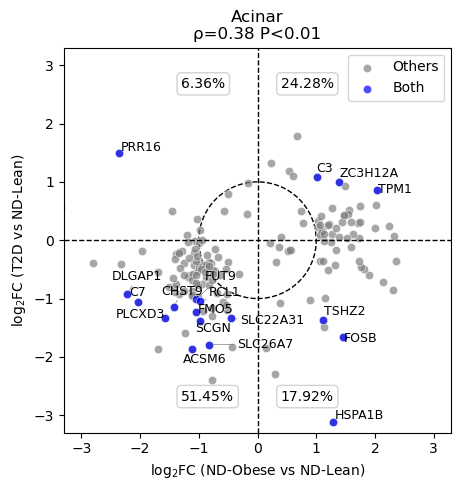

In [ ]:
from adjustText import adjust_text
from scipy.stats import spearmanr

# group genes
scatter_genes = list(
    set(set(sig_genes['ND-Obese']) | set(set(sig_genes['T2D'])))
    & set(protein_coding_genes)
    & set(compare_dfs['ND-Obese'].index)
    & set(compare_dfs['T2D'].index)
                    )
log2FC_df = pd.DataFrame(index=scatter_genes, columns=['ND-Obese', 'T2D', 'Group'])
for group in ['ND-Obese', 'T2D']:
    log2FC_df[group] = compare_dfs[group].loc[scatter_genes, 'memento_log2FC']  # 'deseq_pseudo_bulk_log2FC'
log2FC_df['Group'] = 'Others'
log2FC_df.loc[log2FC_df.index.isin(
    list(set(sig_genes['ND-Obese']) & set(sig_genes['T2D']))), 'Group'] = 'Both'

log2FC_df.to_csv(
    os.path.join('../../tables/pathway_analysis/', f'{ct}_obese_T2D_sig_genes_memento_log2FC_rF1.tsv'), sep='\t')

## plot the location of same genes as with donor F1
log2FC_df_org = pd.read_csv(
    os.path.join('../../tables/pathway_analysis/', f'{ct}_obese_T2D_sig_genes_memento_log2FC_wV2.tsv'), 
    sep='\t', index_col=0)

# plotting
fig, ax = plt.subplots(figsize=[5, 5])
sns.scatterplot(log2FC_df, 
                x='ND-Obese', y='T2D', 
                color='gray',
                label='Others',
                alpha=0.7)

# add auxiliary lines
circle = plt.Circle((0, 0), 1, color='k', fill=False, ls='--', zorder=0, lw=1)
ax.add_patch(circle)
for i in [0,]:
    ax.axvline(i, ls='--', lw=1, c='k')
for i in [0]:
    ax.axhline(i, ls='--', lw=1, c='k')

# figure settings
ax.set_xlim([-3.3, 3.3])
ax.set_ylim([-3.3, 3.3])
# ax.set_title(ct)
ax.set_xlabel(f'log$_2$FC (ND-Obese vs ND-Lean)') # memento
ax.set_ylabel(f'log$_2$FC (T2D vs ND-Lean)')
ax.legend(bbox_to_anchor=[0, 1], title='Group',  loc='upper left')

# Annotate selected genes
genes_to_annotate = log2FC_df_org[log2FC_df_org['Group'] == 'Both'].index.tolist()
genes_to_annotate = list(set(genes_to_annotate) & set(log2FC_df.index)) # make sure the gene exist
texts = []
for gene in genes_to_annotate:
    gx = log2FC_df.loc[gene]['ND-Obese']
    gy = log2FC_df.loc[gene]['T2D']
    texts.append(ax.text(gx, gy, gene, fontsize=9))
# Adjust text to avoid overlaps
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

sns.scatterplot(
    log2FC_df.loc[genes_to_annotate], 
    x='ND-Obese', y='T2D', 
    color='blue',
    label='Both',
    alpha=0.7)

# add text
annotate_df = log2FC_df.copy()
rho = spearmanr(annotate_df['ND-Obese'], annotate_df['T2D']).statistic
P = spearmanr(annotate_df['ND-Obese'], annotate_df['T2D']).pvalue
text = f'ρ={rho:.2f} P={P:.2f}' if P > 0.01 else f'ρ={rho:.2f} P<0.01'
# ax.text(0, 2.8, text, va='top', ha='center')
ax.set_title(f'{ct}\n{text}')
# quadrant 1
pct1 = 100 * (
    (annotate_df['ND-Obese'] > 0)
    & (annotate_df['T2D'] > 0)
).sum() / annotate_df.shape[0]
ax.text(1.3, 2.8, f'{pct1:.2f}%', va='top', ha='right', 
        bbox=dict(
        facecolor='white',          # background color
        edgecolor='lightgray',          # border color
        boxstyle='round,pad=0.3',   # rounded box, with padding
        linewidth=1                 # border width
    ))
# quadrant 2
pct2 = 100 * (
    (annotate_df['ND-Obese'] < 0)
    & (annotate_df['T2D'] > 0)
).sum() / annotate_df.shape[0]
ax.text(-1.3, 2.8, f'{pct2:.2f}%', va='top', ha='left',
        bbox=dict(
        facecolor='white',          # background color
        edgecolor='lightgray',          # border color
        boxstyle='round,pad=0.3',   # rounded box, with padding
        linewidth=1                 # border width
    ))
# quadrant 3
pct3 = 100 * (
    (annotate_df['ND-Obese'] < 0)
    & (annotate_df['T2D'] < 0)
).sum() / annotate_df.shape[0]
ax.text(-1.3, -2.8, f'{pct3:.2f}%', va='bottom', ha='left',
        bbox=dict(
        facecolor='white',          # background color
        edgecolor='lightgray',          # border color
        boxstyle='round,pad=0.3',   # rounded box, with padding
        linewidth=1                 # border width
    ))
# quadrant 4
pct4 = 100 * (
    (annotate_df['ND-Obese'] > 0)
    & (annotate_df['T2D'] < 0)
).sum() / annotate_df.shape[0]
ax.text(1.3, -2.8, f'{pct4:.2f}%', va='bottom', ha='right',
        bbox=dict(
        facecolor='white',          # background color
        edgecolor='lightgray',          # border color
        boxstyle='round,pad=0.3',   # rounded box, with padding
        linewidth=1                 # border width
    ))

# save figure
fig.savefig(
    os.path.join(
        f'../../figures/manuscript_figures/obese_rF1/', f'{ct}_scatter_sig_DEGs_show_original_genes.png'), 
    dpi=300, bbox_inches='tight'
)
fig.savefig(
    os.path.join(
        f'../../figures/manuscript_figures/obese_rF1/', f'{ct}_scatter_sig_DEGs_show_original_genes.pdf'), 
    dpi=300, bbox_inches='tight'
)

In [161]:
acinar_up_genes = list(
    set(set(up_sig_genes['ND-Obese']) | set(sig_genes['T2D'])) 
    & set(protein_coding_genes)
    )
acinar_down_genes = list(
    set(set(down_sig_genes['ND-Obese']) | set(down_sig_genes['T2D'])) 
    & set(protein_coding_genes)
    )

In [162]:
gene_sets = ['GO_Biological_Process_2023', 'Reactome_Pathways_2024']
fig_FDR = 0.1
n_entities = 1

acinar_up_all = get_pth_res(acinar_up_genes, gene_sets, fig_FDR, n_entities)
acinar_up_all.to_csv(
    os.path.join(
        '../../figures/manuscript_figures/obese_rF1/',
        f'up_pathways_acinar_both_obese_T2D_rF1.tsv'), 
    sep='\t')

acinar_up_all_f = acinar_up_all[
    acinar_up_all['Gene_set'] == 'Reactome_Pathways_2024'][:2]

acinar_up_all_f

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Pathway identifier,#Entities found,#Entities total
1173,Reactome_Pathways_2024,Cytokine Signaling in Immune System,25/776,1.424431e-11,1.072596e-08,0,0,6.302817,157.410745,CEBPD;NLRC5;CXCL2;RELB;TRIM29;UBC;GBP2;JUNB;IL...,Cytokine Signaling in Immune Syste,25,776
1174,Reactome_Pathways_2024,Immune System,37/2150,7.329550e-09,2.759576e-06,0,0,3.494456,65.455893,CRP;SERPINA3;CEBPD;NLRC5;TNFAIP3;C4BPA;C4BPB;C...,Immune Syste,37,2150


In [164]:
gene_sets = ['GO_Biological_Process_2023', 'Reactome_Pathways_2024']
fig_FDR = 0.1
n_entities = 1

acinar_down_all = get_pth_res(acinar_down_genes, gene_sets, fig_FDR, n_entities)
acinar_down_all.to_csv(
    os.path.join(
        '../../figures/manuscript_figures/obese_rF1/',
        f'down_pathways_acinar_both_obese_T2D_rF1.tsv'), 
    sep='\t')

down_pths = [
    'Retinoid Metabolism and Transport',
    'Metabolism of Carbohydrates',
    'Metabolism of Fat-Soluble Vitamins',
    'Metabolism of Vitamins and Cofactors',
    'Metabolism',
]
acinar_down_all_f = acinar_down_all[
    (acinar_down_all['Gene_set'] == 'Reactome_Pathways_2024') & 
    (acinar_down_all['Term'].isin(down_pths))
    ]

acinar_down_all_f

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Pathway identifier,#Entities found,#Entities total
720,Reactome_Pathways_2024,Metabolism,43/2181,2.589497e-15,4.619663e-14,0,0,5.668463,190.388451,PRPS2;INSIG1;RPLP1;RPLP0;RPL36A;ACSM6;RPL9;CYP...,Metabolis,43,2181
741,Reactome_Pathways_2024,Retinoid Metabolism and Transport,4/44,8.595012e-05,8.333425e-04,0,0,19.464706,182.223582,CLPS;GPC3;GPC6;LDLR,Retinoid Metabolism and Transpor,4,44
742,Reactome_Pathways_2024,Metabolism of Fat-Soluble Vitamins,4/48,1.212100e-04,1.150206e-03,0,0,17.691622,159.542795,CLPS;GPC3;GPC6;LDLR,Metabolism of Fat-Soluble Vitamin,4,48
743,Reactome_Pathways_2024,Metabolism of Carbohydrates,8/290,1.566460e-04,1.455502e-03,0,0,5.677233,49.741199,PRPS2;CHST9;FUT9;GPC3;ALDOB;GPC6;ABO;PCK2,Metabolism of Carbohydrate,8,290
751,Reactome_Pathways_2024,Metabolism of Vitamins and Cofactors,6/198,6.552523e-04,5.218616e-03,0,0,6.156875,45.132912,HSP90AA1;CLPS;MTHFD1L;GPC3;GPC6;LDLR,Metabolism of Vitamins and Cofactor,6,198


/tmp/ipykernel_2407824/1050917189.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acinar_down_all_f['Type'] = 'Down'


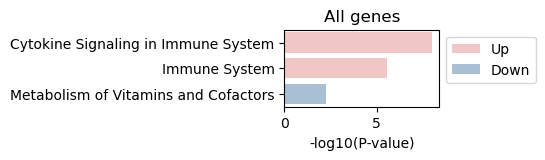

In [166]:
# create the dataframe for plotting
acinar_up_all_f['Type'] = 'Up'
acinar_down_all_f['Type'] = 'Down'
acinar_pth_tmp = pd.concat([acinar_up_all_f, acinar_down_all_f[-1:]])
acinar_pth_tmp['-log10(P-value)'] = -np.log10(acinar_pth_tmp['Adjusted P-value'])

# plotting
fig, ax = plt.subplots(1, 1, figsize=[2, 1])

ax = sns.barplot(
    y='Term', x='-log10(P-value)', 
    data=acinar_pth_tmp, ax=ax, hue='Type',
    palette=['lightcoral', 'steelblue'],
    alpha=0.5
    )

ax.set_ylabel(None)
ax.legend(title=None, bbox_to_anchor=[1, 1])
ax.set_title('All genes')
plt.show()

fig.savefig(
    os.path.join(
        '../../figures/manuscript_figures/obese_rF1/', 
        f'pathways_acinar_both_obese_T2D_all_genes.pdf'), 
    dpi=300, bbox_inches='tight')
fig.savefig(
    os.path.join(
        '../../figures/manuscript_figures/obese_rF1/', 
        f'pathways_acinar_both_obese_T2D_all_genes.png'), 
    dpi=300, bbox_inches='tight')

# Ductal cells [Obese and T2D]

In [16]:
ct_obs = 'cell_type'
ct = 'Ductal'
memento_log2FC = 1
deseq_de_log2FC = 1
memento_de_pval_adj = 0.05

compare_dfs = {}
for group in ['ND-Obese', 'Pre-T2D', 'T2D']:
    deseq_df = DEG_res[('DESeq', '_by_Sex', group, ct)]
    memento_df = DEG_res[('memento', '_by_sex', group, ct)]
    # merge DESeq and memento results
    common_genes = list(set(memento_df.index) & set(deseq_df.index))
    compare_df = pd.concat([memento_df.loc[common_genes], deseq_df.loc[common_genes]], axis=1)

    compare_df['Group'] = 'ns'
    if group != 'Pre-T2D':
        # for groups other than Pre-T2D, get DEGs based on both memento and DESeq
        compare_df.loc[
            (((compare_df['memento_log2FC'] > memento_log2FC) 
             & (compare_df['deseq_de_log2FC'] > 0))
            | 
            ((compare_df['deseq_de_log2FC'] > deseq_de_log2FC)
            & (compare_df['memento_log2FC'] > 0))) 
            & (compare_df['memento_de_pval_adj'] < memento_de_pval_adj),
            'Group'] = 'Up'

        compare_df.loc[
            (((compare_df['memento_log2FC'] < - memento_log2FC) 
             & (compare_df['deseq_de_log2FC'] < 0))
            | 
            ((compare_df['deseq_de_log2FC'] < - deseq_de_log2FC)
            & (compare_df['memento_log2FC'] < 0)))
            & (compare_df['memento_de_pval_adj'] < memento_de_pval_adj),
            'Group'] = 'Down'
        compare_dfs[group] = compare_df
    else:
        # for Pre-T2D, get DEGs based on DESeq
        compare_df.loc[
            (compare_df['deseq_de_log2FC'] > deseq_de_log2FC)
            & (compare_df['memento_log2FC'] > memento_log2FC)
            & (compare_df['memento_de_pval_adj'] < memento_de_pval_adj),
            'Group'] = 'Up'

        compare_df.loc[ 
            (compare_df['deseq_de_log2FC'] < - deseq_de_log2FC)
            & (compare_df['memento_log2FC'] < - memento_log2FC)
            & (compare_df['memento_de_pval_adj'] < memento_de_pval_adj),
            'Group'] = 'Down'
        compare_dfs[group] = compare_df

# get family genes
sig_genes = {
    group: compare_dfs[group][compare_dfs[group]['Group'] != 'ns'].index.tolist()
    for group in ['ND-Obese', 'Pre-T2D', 'T2D']
}

up_sig_genes = {
    group: compare_dfs[group][compare_dfs[group]['Group'] == 'Up'].index.tolist()
    for group in ['ND-Obese', 'Pre-T2D', 'T2D']
}

down_sig_genes = {
    group: compare_dfs[group][compare_dfs[group]['Group'] == 'Down'].index.tolist()
    for group in ['ND-Obese', 'Pre-T2D', 'T2D']
}

all_genes = list(set(gene for genes in sig_genes.values() for gene in genes)) # all DEGs from each group vs lean

# the median pseudo-bulk expression of these DEGs in every group
pseu_bu_median = pd.DataFrame(index=all_genes, columns=['ND-Lean', 'ND-Obese', 'Pre-T2D', 'T2D'])
pseudo_bulk_exp = pd.read_csv(
    os.path.join(pseudo_sum  , f'{ct_obs}_{ct}_pseudo_bulk_sum_counts.tsv'), 
    sep='\t', index_col=0)
pseudo_bulk_exp_log2cpm = np.log2(pseudo_bulk_exp * 1e6 / pseudo_bulk_exp.sum() + 1)

for col in pseu_bu_median.columns:    
    donors = list(set(group_donor_dict[col]) & set(pseudo_bulk_exp_log2cpm.columns))
    pseu_bu_median[col] = pseudo_bulk_exp_log2cpm[donors].median(axis=1).loc[all_genes]

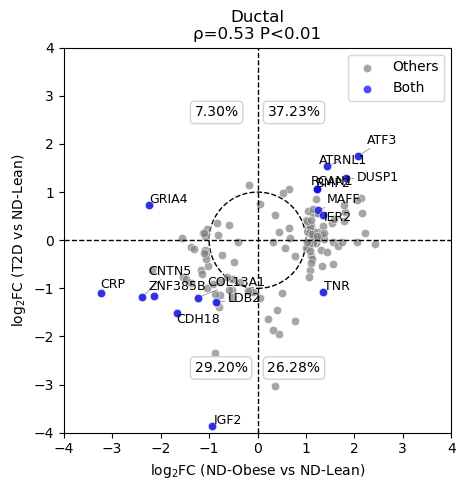

In [ ]:
from adjustText import adjust_text
from scipy.stats import spearmanr

# group genes
scatter_genes = list(
    set(set(sig_genes['ND-Obese']) | set(set(sig_genes['T2D'])))
    & set(protein_coding_genes)
    & set(compare_dfs['ND-Obese'].index)
    & set(compare_dfs['T2D'].index)
                    )
log2FC_df = pd.DataFrame(index=scatter_genes, columns=['ND-Obese', 'T2D', 'Group'])
for group in ['ND-Obese', 'T2D']:
    log2FC_df[group] = compare_dfs[group].loc[scatter_genes, 'memento_log2FC']  # 'deseq_pseudo_bulk_log2FC'
log2FC_df['Group'] = 'Others'
log2FC_df.loc[log2FC_df.index.isin(
    list(set(sig_genes['ND-Obese']) & set(sig_genes['T2D']))), 'Group'] = 'Both'

log2FC_df.to_csv(
    os.path.join('../../tables/pathway_analysis/', f'{ct}_obese_T2D_sig_genes_memento_log2FC_rF1.tsv'), sep='\t')

## plot the location of same genes as with donor F1
log2FC_df_org = pd.read_csv(
    os.path.join('../../tables/pathway_analysis/', f'{ct}_obese_T2D_sig_genes_memento_log2FC_wV2.tsv'), 
    sep='\t', index_col=0)

# plotting
fig, ax = plt.subplots(figsize=[5, 5])
sns.scatterplot(log2FC_df, 
                x='ND-Obese', y='T2D', 
                color='gray',
                label='Others',
                alpha=0.7)

# add auxiliary lines
circle = plt.Circle((0, 0), 1, color='k', fill=False, ls='--', zorder=0, lw=1)
ax.add_patch(circle)
for i in [0,]:
    ax.axvline(i, ls='--', lw=1, c='k')
for i in [0]:
    ax.axhline(i, ls='--', lw=1, c='k')

# figure settings
ax.set_xlim([-4, 4])
ax.set_ylim([-4, 4])
# ax.set_title(ct)
ax.set_xlabel(f'log$_2$FC (ND-Obese vs ND-Lean)') # memento
ax.set_ylabel(f'log$_2$FC (T2D vs ND-Lean)')
ax.legend(bbox_to_anchor=[0, 1], title='Group',  loc='upper left')

# Annotate selected genes
genes_to_annotate = log2FC_df_org[log2FC_df_org['Group'] == 'Both'].index.tolist()
genes_to_annotate = list(set(genes_to_annotate) & set(log2FC_df.index)) # make sure the gene exist
texts = []
for gene in genes_to_annotate:
    gx = log2FC_df.loc[gene]['ND-Obese']
    gy = log2FC_df.loc[gene]['T2D']
    texts.append(ax.text(gx, gy, gene, fontsize=9))
# Adjust text to avoid overlaps
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

sns.scatterplot(
    log2FC_df.loc[genes_to_annotate], 
    x='ND-Obese', y='T2D', 
    color='blue',
    label='Both',
    alpha=0.7)

# add text
annotate_df = log2FC_df.copy()
rho = spearmanr(annotate_df['ND-Obese'], annotate_df['T2D']).statistic
P = spearmanr(annotate_df['ND-Obese'], annotate_df['T2D']).pvalue
text = f'ρ={rho:.2f} P={P:.2f}' if P > 0.01 else f'ρ={rho:.2f} P<0.01'
# ax.text(0, 2.8, text, va='top', ha='center')
ax.set_title(f'{ct}\n{text}')
# quadrant 1
pct1 = 100 * (
    (annotate_df['ND-Obese'] > 0)
    & (annotate_df['T2D'] > 0)
).sum() / annotate_df.shape[0]
ax.text(1.3, 2.8, f'{pct1:.2f}%', va='top', ha='right', 
        bbox=dict(
        facecolor='white',          # background color
        edgecolor='lightgray',          # border color
        boxstyle='round,pad=0.3',   # rounded box, with padding
        linewidth=1                 # border width
    ))
# quadrant 2
pct2 = 100 * (
    (annotate_df['ND-Obese'] < 0)
    & (annotate_df['T2D'] > 0)
).sum() / annotate_df.shape[0]
ax.text(-1.3, 2.8, f'{pct2:.2f}%', va='top', ha='left',
        bbox=dict(
        facecolor='white',          # background color
        edgecolor='lightgray',          # border color
        boxstyle='round,pad=0.3',   # rounded box, with padding
        linewidth=1                 # border width
    ))
# quadrant 3
pct3 = 100 * (
    (annotate_df['ND-Obese'] < 0)
    & (annotate_df['T2D'] < 0)
).sum() / annotate_df.shape[0]
ax.text(-1.3, -2.8, f'{pct3:.2f}%', va='bottom', ha='left',
        bbox=dict(
        facecolor='white',          # background color
        edgecolor='lightgray',          # border color
        boxstyle='round,pad=0.3',   # rounded box, with padding
        linewidth=1                 # border width
    ))
# quadrant 4
pct4 = 100 * (
    (annotate_df['ND-Obese'] > 0)
    & (annotate_df['T2D'] < 0)
).sum() / annotate_df.shape[0]
ax.text(1.3, -2.8, f'{pct4:.2f}%', va='bottom', ha='right',
        bbox=dict(
        facecolor='white',          # background color
        edgecolor='lightgray',          # border color
        boxstyle='round,pad=0.3',   # rounded box, with padding
        linewidth=1                 # border width
    ))

# save figure
fig.savefig(
    os.path.join(
        f'../../figures/manuscript_figures/obese_rF1/', f'{ct}_scatter_sig_DEGs_show_original_genes.png'), 
    dpi=300, bbox_inches='tight'
)
fig.savefig(
    os.path.join(
        f'../../figures/manuscript_figures/obese_rF1/', f'{ct}_scatter_sig_DEGs_show_original_genes.pdf'), 
    dpi=300, bbox_inches='tight'
)

In [168]:
ductal_up_genes = list(
    set(set(up_sig_genes['ND-Obese']) | set(sig_genes['T2D'])) 
    & set(protein_coding_genes)
    )
ductal_down_genes = list(
    set(set(down_sig_genes['ND-Obese']) | set(down_sig_genes['T2D'])) 
    & set(protein_coding_genes)
    )

In [169]:
gene_sets = ['GO_Biological_Process_2023', 'Reactome_Pathways_2024']
fig_FDR = 0.1
n_entities = 1

ductal_up_all = get_pth_res(ductal_up_genes, gene_sets, fig_FDR, n_entities)
ductal_up_all.to_csv(
    os.path.join(
        '../../figures/manuscript_figures/obese_rF1/',
        f'up_pathways_ductal_both_obese_T2D_rF1.tsv'), 
    sep='\t')

ductal_up_all_f = ductal_up_all[
    ductal_up_all['Gene_set'] == 'Reactome_Pathways_2024'][:2]

ductal_up_all_f

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Pathway identifier,#Entities found,#Entities total
1485,Reactome_Pathways_2024,Cytokine Signaling in Immune System,22/776,1.510176e-08,0.000011,0,0,4.848322,87.310788,IL32;EGR1;JUN;MEF2C;MX1;HLA-B;CXCL1;FOS;RELB;H...,Cytokine Signaling in Immune Syste,22,776
1486,Reactome_Pathways_2024,MyD88 MAL(TIRAP) Cascade Initiated on Plasma M...,8/115,1.261067e-06,0.000222,0,0,11.450264,155.535266,SIGIRR;NFKBIA;FGA;MEF2C;JUN;UBC;FOS;NFKB2,TIRAP) Cascade Initiated on Plasma Membran,8,115


In [170]:
gene_sets = ['GO_Biological_Process_2023', 'Reactome_Pathways_2024']
fig_FDR = 0.1
n_entities = 1

ductal_down_all = get_pth_res(ductal_down_genes, gene_sets, fig_FDR, n_entities)
ductal_down_all.to_csv(
    os.path.join(
        '../../figures/manuscript_figures/obese_rF1/',
        f'down_pathways_ductal_both_obese_T2D_rF1.tsv'), 
    sep='\t')

ductal_down_all_f = ductal_down_all[
    ductal_down_all['Gene_set'] == 'Reactome_Pathways_2024'][:2]

ductal_down_all_f

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Pathway identifier,#Entities found,#Entities total
502,Reactome_Pathways_2024,Integrin Cell Surface Interactions,4/85,0.000108,0.028353,0,0,18.162780,165.851092,FGA;VCAM1;COL13A1;SPP1,Integrin Cell Surface Interaction,4,85
503,Reactome_Pathways_2024,Extracellular Matrix Organization,6/300,0.000228,0.029836,0,0,7.711146,64.675098,FGA;VCAM1;COL13A1;ADAMTS1;SPP1;TNR,Extracellular Matrix Organizatio,6,300


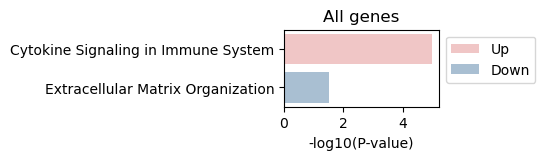

In [171]:
# create the dataframe for plotting
ductal_up_all_f['Type'] = 'Up'
ductal_down_all_f['Type'] = 'Down'
ductal_pth_tmp = pd.concat([ductal_up_all_f[:1], ductal_down_all_f[-1:]])
ductal_pth_tmp['-log10(P-value)'] = -np.log10(ductal_pth_tmp['Adjusted P-value'])

# plotting
fig, ax = plt.subplots(1, 1, figsize=[2, 1])

ax = sns.barplot(
    y='Term', x='-log10(P-value)', 
    data=ductal_pth_tmp, ax=ax, hue='Type',
    palette=['lightcoral', 'steelblue'],
    alpha=0.5
    )

ax.set_ylabel(None)
ax.legend(title=None, bbox_to_anchor=[1, 1])
ax.set_title('All genes')
plt.show()

fig.savefig(
    os.path.join(
        '../../figures/manuscript_figures/obese_rF1/', 
        f'pathways_ductal_both_obese_T2D_all_genes_rF1.pdf'), 
    dpi=300, bbox_inches='tight')
fig.savefig(
    os.path.join(
        '../../figures/manuscript_figures/obese_rF1/', 
        f'pathways_ductal_both_obese_T2D_all_genes_rF1.png'), 
    dpi=300, bbox_inches='tight')

# Enrichment score of immune genes in different cell types (ND-Lean vs ND-Obese/T2D)

In [ ]:
go_library = pd.read_csv(
    '/home/yike/resources/pathway_analyses/GO/GO_level1_pathway_name_ID.tsv', 
    sep='\t',
) # 'Level1_name'
go_library['Index'] = go_library['Name'] + ' (' + go_library['GO_ID'] + ')_G'
go_library = go_library.set_index('GO_ID')

re_library = pd.read_csv(
    '/home/yike/resources/pathway_analyses/Reactome/reactome_root_pathway_name_ID.tsv', 
    sep='\t') # 'Root_Pathway_Name'
re_library['Index'] = re_library['Pathway_Name'] + '_R'
re_library = re_library.set_index('Pathway_Name')
re_library.index = re_library.index.str.title()

In [ ]:
from itertools import chain

def get_genes_of_root_pth(root_pth):
    genes = []
    gene_set = 'Reactome'
    topn = 20
    DEG_type = 'Up'

    groups = ['ND-Obese', 'Pre-T2D', 'T2D']
    ref = 'ND-Lean'
    
    # get the same genes as with all donors
    res_path = '../../tables/pathway_analysis/obese_wV2/analysis/'
    
    for ct in [
           'Acinar', 
           'Ductal', 
           'Stellate',
           'Endothelial',
           'Idling_acinar',
           'Intermediate_acinar',
           'Basal_ductal', 
           'Inflam_ductal_1', 
           'Inflam_ductal_2', 
           'Activated_stellates',
           'α', 'β',

    ]:
        # pathway pvalues
        pth_pvals = pd.read_csv(
                    os.path.join(res_path, f'{ct}_all_pathways.tsv'), 
                    sep='\t', index_col=0)
        pth_pvals = pth_pvals[pth_pvals.index.str.endswith(f'_{gene_set[0]}')]

        # select needed pathways - topn pathways
        mask = pd.Series(False, index=pth_pvals.index)
        for col in pth_pvals.columns:
            above = pth_pvals[pth_pvals[col] > 0][col].sort_values()
            if len(above) >= topn:
                val = above.iloc[-topn]
            else:
                val = above.min() if not above.empty else float('inf')
            mask |= (pth_pvals[col] >= val)
        pth_pvals = pth_pvals[mask]

        pth_pvals['Index'] = pth_pvals.index.str.removesuffix(f'_{gene_set[0]}')
        pth_pvals = pth_pvals.set_index('Index')


        if gene_set == 'GO': # GO pathways
            col_pths = pth_pvals.index.map(
                lambda x: go_library.loc[x, 'Level1_name']
                if x in go_library.index
                else np.nan)
        elif gene_set == 'Reactome': # reactome pathways
            col_pths = pth_pvals.index.map(
                lambda x: re_library.loc[x.title(), 'Root_Pathway_Name']
                if x.title() in re_library.index
                else np.nan)

        col_pths = pd.Series(col_pths)
        pth_pvals['Root_pathway'] = col_pths.tolist()

        # pathways related with immune system
        immune_pths = pth_pvals[pth_pvals['Root_pathway'] == root_pth].index

        for group in groups:
            fn = f'{ct}_{DEG_type}_{group}_vs_{ref}.tsv'
            if fn in os.listdir('../../tables/pathway_analysis/obese_wV2/results/'):
                ct_df = pd.read_csv(
                    os.path.join('../../tables/pathway_analysis/obese_wV2/results/', fn), 
                    sep='\t', index_col='Term')

                valid_immune_pths = list(set(ct_df.index) & set(immune_pths))
                immune_set_ct = set(chain.from_iterable(
                        ct_df.loc[valid_immune_pths]['Genes'].str.split(';')
                    ))
                genes += list(immune_set_ct)

        genes = pd.Series(genes).unique().tolist()
        genes = pd.Series(genes).replace({
            'C21ORF91': 'C21orf91', 
            'C10ORF90': 'C10orf90'
        }).tolist()
        
    return genes         

In [ ]:
from statannotations.Annotator import Annotator

def plot_immune_score(adata, groups):
    # Subset data
    df = adata.obs[
        adata.obs['group'].isin(groups)
    ].copy()
    df['group'] = df['group'].astype('str')

    fig = plt.figure(figsize=(5, 3))

    ax = sns.violinplot(
        data=df,
        x='cell_type',
        y='immune_score',
        hue='group',
        split=True,
        inner='quartile',
        hue_order=groups,
        palette=[group_colors[groups[0]], group_colors[groups[1]]]
    )

    plt.xlabel(None)
    plt.ylabel('Immune Score')
    plt.xticks(rotation=45, ha='right')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

    # Define comparisons for each cell type
    pairs = [
        ((ct, 'ND-Lean'), (ct, 'ND-Obese'))
        for ct in df['cell_type'].unique()
    ]

    annotator = Annotator(
        ax,
        pairs,
        data=df,
        x='cell_type',
        y='immune_score',
        hue='group',
        hue_order=groups,
        palette=[group_colors[groups[0]], group_colors[groups[1]]]
    )

    annotator.configure(
        test='Mann-Whitney',
        text_format='star',
        loc='outside',
        comparisons_correction="BH",   # Benjamini-Hochberg FDR
        hide_non_significant=True      # only significant
    )

    annotator.apply_and_annotate()

    plt.tight_layout()

    return fig

In [127]:
immune_genes = get_genes_of_root_pth('Immune System')

sc.tl.score_genes(
    adata,
    immune_genes,
    score_name='immune_score',
    use_raw=False
)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Acinar_ND-Lean vs. Acinar_ND-Obese: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:0.000e+00 U_stat=4.250e+07
Endocrine_ND-Lean vs. Endocrine_ND-Obese: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.862e-02 U_stat=1.967e+05
Ductal_ND-Lean vs. Ductal_ND-Obese: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.900e-98 U_stat=9.322e+06
Stellate_ND-Lean vs. Stellate_ND-Obese: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.341e-11 U_stat=1.065e+05
Immune_ND-Lean vs. Immune_ND-Obese: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.116e-26 U_stat=2.152e+04


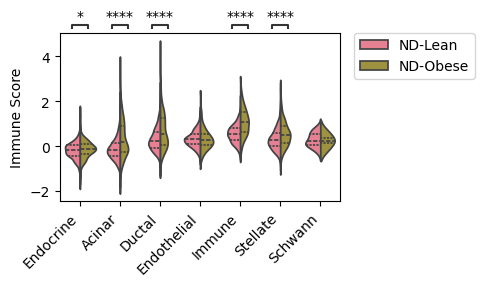

In [ ]:
fig = plot_immune_score(adata, ['ND-Lean', 'ND-Obese'])

# save figure
fig.savefig(
    os.path.join(
        f'../../figures/manuscript_figures/obese_rF1/', 
        f'immune_score_obese_vs_lean_by_cell_type.png'), 
    dpi=300, bbox_inches='tight'
)
fig.savefig(
    os.path.join(
        f'../../figures/manuscript_figures/obese_rF1/', 
        f'immune_score_obese_vs_lean_by_cell_type.pdf'), 
    dpi=300, bbox_inches='tight'
)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Acinar_ND-Lean vs. Acinar_T2D: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.796e-18 U_stat=6.091e+07
Ductal_ND-Lean vs. Ductal_T2D: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.617e-03 U_stat=1.185e+07


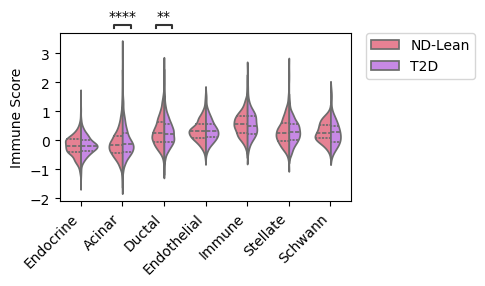

In [ ]:
fig = plot_immune_score(adata, ['ND-Lean', 'T2D'])

# save figure
fig.savefig(
    os.path.join(
        f'../../figures/manuscript_figures/obese_rF1/', 
        f'immune_score_T2D_vs_lean_by_cell_type.png'), 
    dpi=300, bbox_inches='tight'
)
fig.savefig(
    os.path.join(
        f'../../figures/manuscript_figures/obese_rF1/', 
        f'immune_score_T2D_vs_lean_by_cell_type.pdf'), 
    dpi=300, bbox_inches='tight'
)

# Pearson analysis between gene expression and BMI

In [8]:
from scipy.stats import rankdata, t
from sklearn.feature_selection import mutual_info_regression
from statsmodels.stats.multitest import multipletests

def pearson_corr(X, y, gene_exps):
    # 0) Handle NaNs: drop any sample with NaN in y or any gene (global mask)
    mask = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    y = y[mask]
    X = X[mask, :]
    n, p = X.shape

    # 1) Z-score raw data (Pearson uses centered, scaled values)
    y_z = (y - y.mean()) / y.std(ddof=1)                 # (n,)
    X_mean = X.mean(axis=0)                               # (p,)
    X_std  = X.std(axis=0, ddof=1)                        # (p,)
    # avoid divide-by-zero for constant genes
    X_std[X_std == 0] = np.nan
    X_z = (X - X_mean) / X_std                            # (n, p)

    # 2) Correlations in one shot: r = (y_z^T X_z) / (n-1)
    rho = (y_z @ X_z) / (n - 1)                           # (p,)
    # genes with zero variance -> nan; you can set to 0 if you prefer:
    # rho = np.nan_to_num(rho, nan=0.0)

    # 3) Two-sided p-values via t distribution with df = n-2
    #    t = r * sqrt((n-2)/(1-r^2))
    den = np.clip(1 - rho**2, 1e-15, None)
    tvals = rho * np.sqrt((n - 2) / den)
    pvals = 2 * t.sf(np.abs(tvals), df=n - 2)

    # 4) Assemble results (+ optional FDR)
    pearson_corr = pd.DataFrame({'r': rho, 'pval': pvals}, index=gene_exps.index)
    pearson_corr = pearson_corr.sort_values('r', ascending=False)
    
    return pearson_corr

import gseapy as gp
def enrichr_pth(genes, gene_sets, n_entities=1, fig_FDR=False):
    
    all_results = []
    for gs in gene_sets:
        enr = gp.enrichr(
            gene_list=genes,
            gene_sets=gs,
            organism='Human',
            cutoff=False)
        res = enr.res2d.copy()
        all_results.append(res)

    df = pd.concat(all_results, ignore_index=True)

    df['Pathway identifier'] = df['Term'].str.split('(').str[-1].str[:-1]
    df['#Entities found'] = df['Overlap'].str.split('/').str[0].astype('int')
    df['#Entities total'] = df['Overlap'].str.split('/').str[1].astype('int')

    if fig_FDR is not False:
        df_strict = df[
                (df['Adjusted P-value'] < fig_FDR) # < 0.1
                & (df['#Entities found'].astype('int') > n_entities)
            ]
    else:
        df_strict = df[
                (df['#Entities found'].astype('int') > n_entities)
            ]
    return df_strict

## without F1

In [ ]:
ct_obs = 'cell_type'
fea = 'BMI'
method = 'pearsonr'
pct_threshold = 0.7
topn = 300
gene_sets = ['GO_Biological_Process_2023', 'Reactome_Pathways_2024']

##----------------------------------## all cells together
ct = 'all_cells'
#### load feature information
groups = ['ND-Lean', 'ND-Obese', 'Pre-T2D']
parse_donors = adata.obs['sample'].unique().tolist()
fea_donors_all = metadata.loc[parse_donors][metadata.loc[parse_donors]['group'].isin(groups)][[fea]].dropna().index.to_list()
feas = metadata.loc[fea_donors_all][fea]

#### load expression data
pseudo_sum = '../../tables/DESeq/pseudo_bulk_sum/obese_rF1/'
pseudo_bulk_exp = pd.read_csv(
        os.path.join(pseudo_sum  , f'{ct_obs}_{ct}_pseudo_bulk_sum_counts.tsv'), 
        sep='\t', index_col=0)
pseudo_bulk_exp_log2cpm = np.log2(pseudo_bulk_exp * 1e6 / pseudo_bulk_exp.sum() + 1)
gene_exps = pseudo_bulk_exp_log2cpm[fea_donors_all].copy()

#### spearman analysis for all cells
y = np.asarray(feas, dtype=float)    # (n_samples,)
X = gene_exps.T.values.astype(float) # (n_samples, n_genes)  transpose once

all_corr = pearson_corr(X, y, gene_exps) # --> direct function for spearman analysis
all_corr['median_log2cpm'] = gene_exps.median(axis=1).loc[all_corr.index]
all_corr['n_exp'] = (gene_exps > 0).sum(axis=1).loc[all_corr.index]
all_corr['pct_exp'] = all_corr['n_exp'] / len(fea_donors_all)
outpath = f'../../figures/manuscript_figures/obese_rF1/correlation/{fea}/{method}/{ct}_{method}_{fea}_exp_rF1.tsv'

with open(outpath, "w") as f:
    f.write(f"# {len(groups)} groups used: " + ",".join(groups) + "\n")
    f.write(f"# all donors included\n")
    f.write(f"# {len(fea_donors_all)} donors used: " + ",".join(fea_donors_all) + "\n")
    f.write("# pseudo-bulk log2cpm is used\n")
    f.write(f"# {method} analysis\n")
    all_corr.to_csv(f, sep="\t")

#### filter out genes
all_corr = all_corr[(all_corr['pct_exp'] > pct_threshold) & (all_corr.index.isin(protein_coding_genes))].copy()

#### pathway analysis
pos_genes = all_corr.head(topn).index.tolist()
pos_pths = enrichr_pth(pos_genes, gene_sets, n_entities=1, fig_FDR=0.1)
pos_pths.to_csv(
    f'../../figures/manuscript_figures/obese_rF1/correlation/{fea}/{method}/{ct}_top{topn}_{method}_pos_pathway_analysis_rF1.tsv', 
    sep='\t', index=False)

neg_genes = all_corr.tail(topn).index.tolist()
neg_pths = enrichr_pth(neg_genes, gene_sets, n_entities=1, fig_FDR=0.1)
neg_pths.to_csv(
    f'../../figures/manuscript_figures/obese_rF1/correlation/{fea}/{method}/{ct}_top{topn}_{method}_neg_pathway_analysis_rF1.tsv', 
    sep='\t', index=False)

##----------------------------------## each celltype
nfold = 1.1
rho_threshold = 0.6
cts = ['Acinar', 'Ductal', 'Endocrine', 'Endothelial', 'Immune', 'Stellate']

ct_n_thresholds = {
    'Acinar': 105, 'Ductal': 50, 'Endocrine': 20, 'Endothelial': 10, 'Immune': 10, 'Stellate': 10, 'Schwann': 10
}

for ct in cts:
    #### basic information for calculating and plotting
    ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
    fea_donors = ct_numbers.loc[ct_numbers > ct_n_thresholds[ct]].index.tolist()
    feas = metadata.loc[fea_donors][fea]

    pre_fea_donors = metadata.loc[fea_donors][metadata.loc[fea_donors]['group'].isin(['Pre-T2D'])][[fea]].dropna().index.to_list()
    pre_feas = metadata.loc[pre_fea_donors][fea]

    pseudo_bulk_exp = pd.read_csv(
            os.path.join(pseudo_sum  , f'{ct_obs}_{ct}_pseudo_bulk_sum_counts.tsv'), 
            sep='\t', index_col=0)
    pseudo_bulk_exp_log2cpm = np.log2(pseudo_bulk_exp * 1e6 / pseudo_bulk_exp.sum() + 1)

    gene_exps = pseudo_bulk_exp_log2cpm[fea_donors].copy()
    pre_gene_exps = pseudo_bulk_exp_log2cpm[pre_fea_donors].copy()
    
    #### pearsonr analysis
    y = np.asarray(feas, dtype=float)        # (n_samples,)
    X = gene_exps.T.values.astype(float)     # (n_samples, n_genes)  transpose once
    
    ct_corr = pearson_corr(X, y, gene_exps)
    ct_corr['median_log2cpm'] = gene_exps.median(axis=1).loc[ct_corr.index]
    ct_corr['n_exp'] = (gene_exps > 0).sum(axis=1).loc[ct_corr.index]
    ct_corr['pct_exp'] = ct_corr['n_exp'] / len(fea_donors)
    outpath = f'../../figures/manuscript_figures/obese_rF1/correlation/{fea}/{method}/{ct}_{method}_{fea}_exp_rF1.tsv'
    
    with open(outpath, "w") as f:
        f.write(f"# {len(groups)} groups used: " + ",".join(groups) + "\n")
        f.write(f"# donors with <= {ct_n_thresholds[ct]} {ct} are filtered out\n")
        f.write(f"# {len(fea_donors)} donors used: " + ",".join(fea_donors) + "\n")
        f.write("# pseudo-bulk log2cpm is used\n")
        f.write(f"# {method} analysis\n")
        ct_corr.to_csv(f, sep="\t")
    
    #### filter out genes
    ct_corr = ct_corr[(ct_corr['pct_exp'] > pct_threshold) & (ct_corr.index.isin(protein_coding_genes))].copy()
    if ct_corr.shape[0] < topn:
        print(f'{ct}: not enough genes for GSEA')
        continue
    else:
        #### pathway analysis of this cell type
        ct_pos_genes = ct_corr[ct_corr['r'] > 0].head(topn).index.tolist()
        ct_pos_pths = enrichr_pth(ct_pos_genes, gene_sets, n_entities=1, fig_FDR=0.1)
        ct_pos_pths.to_csv(
            f'../../figures/manuscript_figures/obese_rF1/correlation/{fea}/{method}/{ct}_{method}_top{topn}_genes_pos_pathway_analysis_rF1.tsv', 
            sep='\t', index=False)

        ct_neg_genes = ct_corr[ct_corr['r'] < 0].tail(topn).index.tolist()
        ct_neg_pths = enrichr_pth(ct_neg_genes, gene_sets, n_entities=1, fig_FDR=0.1)
        ct_neg_pths.to_csv(
            f'../../figures/manuscript_figures/obese_rF1/correlation/{fea}/{method}/{ct}_{method}_top{topn}_genes_neg_pathway_analysis_rF1.tsv', 
            sep='\t', index=False)

/tmp/ipykernel_2407824/4275968148.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_2407824/4275968148.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_2407824/4275968148.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt 

In [35]:
##### for cell subtypes
cst_obs = 'cell_subtype1'
fea = 'BMI'
method = 'pearsonr'
pct_threshold = 0.7
topn = 300
gene_sets = ['GO_Biological_Process_2023', 'Reactome_Pathways_2024']

##----------------------------------## each celltype
nfold = 1.1
rho_threshold = 0.6
csts = [
        'α', 'β', 'γ', 'δ', 
        # 'Basal_acinar', 'High_enzyme_acinar',
        'Idling_acinar', 'Intermediate_acinar', 'Signaling_acinar',
        'Basal_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2', 'MUC5B+_ductal',
        'Arterial_ECs', 'Venous_ECs', 'Lymphatic_ECs', 'Capillary_ECs', 
        'Macrophages', 'Plasmablasts', 'T_cells', 'Mast_cells',
        'Activated_stellates', 'Quiescent_stellates', 
#         'Schwann'
       ]

cst_n_thresholds = {
    'Acinar': 105, 'Ductal': 50, 'Endocrine': 20, 'Endothelial': 10, 'Immune': 10, 'Stellate': 10, 'Schwann': 10
}
groups = ['ND-Lean', 'ND-Obese', 'Pre-T2D']
parse_donors = adata.obs['sample'].unique().tolist()
fea_donors_all = metadata.loc[parse_donors][metadata.loc[parse_donors]['group'].isin(groups)][[fea]].dropna().index.to_list()

pseudo_sum = '../../tables/DESeq/pseudo_bulk_sum/obese_rF1/'

for cst in csts:
    ct = cst_ct_dic[cst]
    #### basic information for calculating and plotting
    ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
    fea_donors = ct_numbers.loc[ct_numbers > ct_n_thresholds[ct]].index.tolist()

    pseudo_bulk_exp = pd.read_csv(
            os.path.join(pseudo_sum, f'{cst_obs}_{cst}_pseudo_bulk_sum_counts.tsv'), 
            sep='\t', index_col=0)
    pseudo_bulk_exp_log2cpm = np.log2(pseudo_bulk_exp * 1e6 / pseudo_bulk_exp.sum() + 1)
    
    fea_donors = list(set(fea_donors) & set(pseudo_bulk_exp_log2cpm.columns))
    feas = metadata.loc[fea_donors][fea]
    gene_exps = pseudo_bulk_exp_log2cpm[fea_donors].copy()
    
    #### pearsonr analysis
    y = np.asarray(feas, dtype=float)        # (n_samples,)
    X = gene_exps.T.values.astype(float)     # (n_samples, n_genes)  transpose once
    
    cst_corr = pearson_corr(X, y, gene_exps)
    cst_corr['median_log2cpm'] = gene_exps.median(axis=1).loc[cst_corr.index]
    cst_corr['n_exp'] = (gene_exps > 0).sum(axis=1).loc[cst_corr.index]
    cst_corr['pct_exp'] = cst_corr['n_exp'] / len(fea_donors)
    outpath = f'../../figures/manuscript_figures/obese_rF1/correlation/{fea}/{method}/{cst}_{method}_{fea}_exp_rF1.tsv'
    
    with open(outpath, "w") as f:
        f.write(f"# {len(groups)} groups used: " + ",".join(groups) + "\n")
        f.write(f"# donors with <= {cst_n_thresholds[ct]} {ct} are filtered out\n")
        f.write(f"# {len(fea_donors)} donors used: " + ",".join(fea_donors) + "\n")
        f.write("# pseudo-bulk log2cpm is used\n")
        f.write(f"# {method} analysis\n")
        cst_corr.to_csv(f, sep="\t")
    
    #### filter out genes
    cst_corr = cst_corr[(cst_corr['pct_exp'] > pct_threshold) & (cst_corr.index.isin(protein_coding_genes))].copy()
    if cst_corr.shape[0] < topn:
        print(f'{cst}: not enough genes for GSEA')
        continue
    else:
        #### pathway analysis of this cell type
        cst_pos_genes = cst_corr[cst_corr['r'] > 0].head(topn).index.tolist()
        cst_pos_pths = enrichr_pth(cst_pos_genes, gene_sets, n_entities=1, fig_FDR=0.1)
        cst_pos_pths.to_csv(
            f'../../figures/manuscript_figures/obese_rF1/correlation/{fea}/{method}/{cst}_{method}_top{topn}_genes_pos_pathway_analysis_rF1.tsv', 
            sep='\t', index=False)

        cst_neg_genes = cst_corr[cst_corr['r'] < 0].tail(topn).index.tolist()
        cst_neg_pths = enrichr_pth(cst_neg_genes, gene_sets, n_entities=1, fig_FDR=0.1)
        cst_neg_pths.to_csv(
            f'../../figures/manuscript_figures/obese_rF1/correlation/{fea}/{method}/{cst}_{method}_top{topn}_genes_neg_pathway_analysis_rF1.tsv', 
            sep='\t', index=False)

/tmp/ipykernel_202310/3748438794.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_202310/3748438794.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_202310/3748438794.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the

γ: not enough genes for GSEA


/tmp/ipykernel_202310/3748438794.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_202310/3748438794.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_202310/3748438794.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the

Signaling_acinar: not enough genes for GSEA


/tmp/ipykernel_202310/3748438794.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_202310/3748438794.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_202310/3748438794.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the

...

/tmp/ipykernel_202310/3748438794.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_202310/3748438794.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_202310/3748438794.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the

Plasmablasts: not enough genes for GSEA


/tmp/ipykernel_202310/3748438794.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_202310/3748438794.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()


Mast_cells: not enough genes for GSEA


/tmp/ipykernel_202310/3748438794.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()


## exclude V2 & F1

In [32]:
ct_obs = 'cell_type'
fea = 'BMI'
method = 'pearsonr'
pct_threshold = 0.7
topn = 300
gene_sets = ['GO_Biological_Process_2023', 'Reactome_Pathways_2024']

##----------------------------------## all cells together
ct = 'all_cells'
#### load feature information
groups = ['ND-Lean', 'ND-Obese', 'Pre-T2D']
parse_donors = list(set(adata.obs['sample'].unique().tolist()) - set(['V2'])) # exclude V2
fea_donors_all = metadata.loc[parse_donors][metadata.loc[parse_donors]['group'].isin(groups)][[fea]].dropna().index.to_list()
feas = metadata.loc[fea_donors_all][fea]

#### load expression data
pseudo_sum = '../../tables/DESeq/pseudo_bulk_sum/obese_rF1/'
pseudo_bulk_exp = pd.read_csv(
        os.path.join(pseudo_sum  , f'{ct_obs}_{ct}_pseudo_bulk_sum_counts.tsv'), 
        sep='\t', index_col=0)
pseudo_bulk_exp = pseudo_bulk_exp.loc[:, ~ pseudo_bulk_exp.columns.isin(['V2'])].copy() # exclude V2
pseudo_bulk_exp_log2cpm = np.log2(pseudo_bulk_exp * 1e6 / pseudo_bulk_exp.sum() + 1)

gene_exps = pseudo_bulk_exp_log2cpm[fea_donors_all].copy()

#### spearman analysis for all cells
y = np.asarray(feas, dtype=float)    # (n_samples,)
X = gene_exps.T.values.astype(float) # (n_samples, n_genes)  transpose once

all_corr = pearson_corr(X, y, gene_exps) # --> direct function for spearman analysis
all_corr['median_log2cpm'] = gene_exps.median(axis=1).loc[all_corr.index]
all_corr['n_exp'] = (gene_exps > 0).sum(axis=1).loc[all_corr.index]
all_corr['pct_exp'] = all_corr['n_exp'] / len(fea_donors_all)
outpath = f'../../figures/manuscript_figures/obese_rF1/correlation/{fea}/{method}/{ct}_{method}_{fea}_exp_rF1_rV2.tsv'

with open(outpath, "w") as f:
    f.write(f"# {len(groups)} groups used: " + ",".join(groups) + "\n")
    f.write(f"# all donors included\n")
    f.write(f"# {len(fea_donors_all)} donors used: " + ",".join(fea_donors_all) + "\n")
    f.write("# pseudo-bulk log2cpm is used\n")
    f.write(f"# {method} analysis\n")
    all_corr.to_csv(f, sep="\t")

#### filter out genes
all_corr = all_corr[(all_corr['pct_exp'] > pct_threshold) & (all_corr.index.isin(protein_coding_genes))].copy()

#### pathway analysis
pos_genes = all_corr.head(topn).index.tolist()
pos_pths = enrichr_pth(pos_genes, gene_sets, n_entities=1, fig_FDR=0.1)
pos_pths.to_csv(
    f'../../figures/manuscript_figures/obese_rF1/correlation/{fea}/{method}/{ct}_top{topn}_{method}_pos_pathway_analysis_rF1_rV2.tsv', 
    sep='\t', index=False)

neg_genes = all_corr.tail(topn).index.tolist()
neg_pths = enrichr_pth(neg_genes, gene_sets, n_entities=1, fig_FDR=0.1)
neg_pths.to_csv(
    f'../../figures/manuscript_figures/obese_rF1/correlation/{fea}/{method}/{ct}_top{topn}_{method}_neg_pathway_analysis_rF1_rV2.tsv', 
    sep='\t', index=False)

##----------------------------------## each celltype
nfold = 1.1
rho_threshold = 0.6
cts = ['Acinar', 'Ductal', 'Endocrine', 'Endothelial', 'Immune', 'Stellate']

ct_n_thresholds = {
    'Acinar': 105, 'Ductal': 50, 'Endocrine': 20, 'Endothelial': 10, 'Immune': 10, 'Stellate': 10, 'Schwann': 10
}

for ct in cts:
    #### basic information for calculating and plotting
    ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
    fea_donors = ct_numbers.loc[ct_numbers > ct_n_thresholds[ct]].index.tolist()
    feas = metadata.loc[fea_donors][fea]

    pre_fea_donors = metadata.loc[fea_donors][metadata.loc[fea_donors]['group'].isin(['Pre-T2D'])][[fea]].dropna().index.to_list()
    pre_feas = metadata.loc[pre_fea_donors][fea]

    pseudo_bulk_exp = pd.read_csv(
            os.path.join(pseudo_sum  , f'{ct_obs}_{ct}_pseudo_bulk_sum_counts.tsv'), 
            sep='\t', index_col=0)
    pseudo_bulk_exp = pseudo_bulk_exp.loc[:, ~ pseudo_bulk_exp.columns.isin(['V2'])].copy() # exclude V2
    pseudo_bulk_exp_log2cpm = np.log2(pseudo_bulk_exp * 1e6 / pseudo_bulk_exp.sum() + 1)

    gene_exps = pseudo_bulk_exp_log2cpm[fea_donors].copy()
    pre_gene_exps = pseudo_bulk_exp_log2cpm[pre_fea_donors].copy()
    
    #### pearsonr analysis
    y = np.asarray(feas, dtype=float)        # (n_samples,)
    X = gene_exps.T.values.astype(float)     # (n_samples, n_genes)  transpose once
    
    ct_corr = pearson_corr(X, y, gene_exps)
    ct_corr['median_log2cpm'] = gene_exps.median(axis=1).loc[ct_corr.index]
    ct_corr['n_exp'] = (gene_exps > 0).sum(axis=1).loc[ct_corr.index]
    ct_corr['pct_exp'] = ct_corr['n_exp'] / len(fea_donors)
    outpath = f'../../figures/manuscript_figures/obese_rF1/correlation/{fea}/{method}/{ct}_{method}_{fea}_exp_rF1_rV2.tsv'
    
    with open(outpath, "w") as f:
        f.write(f"# {len(groups)} groups used: " + ",".join(groups) + "\n")
        f.write(f"# donors with <= {ct_n_thresholds[ct]} {ct} are filtered out\n")
        f.write(f"# {len(fea_donors)} donors used: " + ",".join(fea_donors) + "\n")
        f.write("# pseudo-bulk log2cpm is used\n")
        f.write(f"# {method} analysis\n")
        ct_corr.to_csv(f, sep="\t")
    
    #### filter out genes
    ct_corr = ct_corr[(ct_corr['pct_exp'] > pct_threshold) & (ct_corr.index.isin(protein_coding_genes))].copy()
    if ct_corr.shape[0] < topn:
        print(f'{ct}: not enough genes for GSEA')
        continue
    else:
        #### pathway analysis of this cell type
        ct_pos_genes = ct_corr[ct_corr['r'] > 0].head(topn).index.tolist()
        ct_pos_pths = enrichr_pth(ct_pos_genes, gene_sets, n_entities=1, fig_FDR=0.1)
        ct_pos_pths.to_csv(
            f'../../figures/manuscript_figures/obese_rF1/correlation/{fea}/{method}/{ct}_{method}_top{topn}_genes_pos_pathway_analysis_rF1_rV2.tsv', 
            sep='\t', index=False)

        ct_neg_genes = ct_corr[ct_corr['r'] < 0].tail(topn).index.tolist()
        ct_neg_pths = enrichr_pth(ct_neg_genes, gene_sets, n_entities=1, fig_FDR=0.1)
        ct_neg_pths.to_csv(
            f'../../figures/manuscript_figures/obese_rF1/correlation/{fea}/{method}/{ct}_{method}_top{topn}_genes_neg_pathway_analysis_rF1_rV2.tsv', 
            sep='\t', index=False)

/tmp/ipykernel_202310/3113583952.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_202310/3113583952.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_202310/3113583952.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the

In [34]:
##### for cell subtypes
cst_obs = 'cell_subtype1'
fea = 'BMI'
method = 'pearsonr'
pct_threshold = 0.7
topn = 300
gene_sets = ['GO_Biological_Process_2023', 'Reactome_Pathways_2024']

##----------------------------------## each celltype
nfold = 1.1
rho_threshold = 0.6
csts = [
        'α', 'β', 'γ', 'δ', 
        # 'Basal_acinar', 'High_enzyme_acinar',
        'Idling_acinar', 'Intermediate_acinar', 'Signaling_acinar',
        'Basal_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2', 'MUC5B+_ductal',
        'Arterial_ECs', 'Venous_ECs', 'Lymphatic_ECs', 'Capillary_ECs', 
        'Macrophages', 'Plasmablasts', 'T_cells', 'Mast_cells',
        'Activated_stellates', 'Quiescent_stellates', 
#         'Schwann'
       ]

cst_n_thresholds = {
    'Acinar': 105, 'Ductal': 50, 'Endocrine': 20, 'Endothelial': 10, 'Immune': 10, 'Stellate': 10, 'Schwann': 10
}
groups = ['ND-Lean', 'ND-Obese', 'Pre-T2D']
parse_donors = list(set(adata.obs['sample'].unique().tolist()) - set(['V2'])) # exclude V2
fea_donors_all = metadata.loc[parse_donors][metadata.loc[parse_donors]['group'].isin(groups)][[fea]].dropna().index.to_list()

pseudo_sum = '../../tables/DESeq/pseudo_bulk_sum/obese_rF1/'

for cst in csts:
    ct = cst_ct_dic[cst]
    #### basic information for calculating and plotting
    ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
    fea_donors = ct_numbers.loc[ct_numbers > ct_n_thresholds[ct]].index.tolist()

    pseudo_bulk_exp = pd.read_csv(
            os.path.join(pseudo_sum, f'{cst_obs}_{cst}_pseudo_bulk_sum_counts.tsv'), 
            sep='\t', index_col=0)
    pseudo_bulk_exp = pseudo_bulk_exp.loc[:, ~ pseudo_bulk_exp.columns.isin(['V2'])].copy() # exclude V2
    pseudo_bulk_exp_log2cpm = np.log2(pseudo_bulk_exp * 1e6 / pseudo_bulk_exp.sum() + 1)
    
    fea_donors = list(set(fea_donors) & set(pseudo_bulk_exp_log2cpm.columns))
    feas = metadata.loc[fea_donors][fea]
    gene_exps = pseudo_bulk_exp_log2cpm[fea_donors].copy()
    
    #### pearsonr analysis
    y = np.asarray(feas, dtype=float)        # (n_samples,)
    X = gene_exps.T.values.astype(float)     # (n_samples, n_genes)  transpose once
    
    cst_corr = pearson_corr(X, y, gene_exps)
    cst_corr['median_log2cpm'] = gene_exps.median(axis=1).loc[cst_corr.index]
    cst_corr['n_exp'] = (gene_exps > 0).sum(axis=1).loc[cst_corr.index]
    cst_corr['pct_exp'] = cst_corr['n_exp'] / len(fea_donors)
    outpath = f'../../figures/manuscript_figures/obese_rF1/correlation/{fea}/{method}/{cst}_{method}_{fea}_exp_rF1_rV2.tsv'
    
    with open(outpath, "w") as f:
        f.write(f"# {len(groups)} groups used: " + ",".join(groups) + "\n")
        f.write(f"# donors with <= {cst_n_thresholds[ct]} {ct} are filtered out\n")
        f.write(f"# {len(fea_donors)} donors used: " + ",".join(fea_donors) + "\n")
        f.write("# pseudo-bulk log2cpm is used\n")
        f.write(f"# {method} analysis\n")
        cst_corr.to_csv(f, sep="\t")
    
    #### filter out genes
    cst_corr = cst_corr[(cst_corr['pct_exp'] > pct_threshold) & (cst_corr.index.isin(protein_coding_genes))].copy()
    if cst_corr.shape[0] < topn:
        print(f'{cst}: not enough genes for GSEA')
        continue
    else:
        #### pathway analysis of this cell type
        cst_pos_genes = cst_corr[cst_corr['r'] > 0].head(topn).index.tolist()
        cst_pos_pths = enrichr_pth(cst_pos_genes, gene_sets, n_entities=1, fig_FDR=0.1)
        cst_pos_pths.to_csv(
            f'../../figures/manuscript_figures/obese_rF1/correlation/{fea}/{method}/{cst}_{method}_top{topn}_genes_pos_pathway_analysis_rF1_rV2.tsv', 
            sep='\t', index=False)

        cst_neg_genes = cst_corr[cst_corr['r'] < 0].tail(topn).index.tolist()
        cst_neg_pths = enrichr_pth(cst_neg_genes, gene_sets, n_entities=1, fig_FDR=0.1)
        cst_neg_pths.to_csv(
            f'../../figures/manuscript_figures/obese_rF1/correlation/{fea}/{method}/{cst}_{method}_top{topn}_genes_neg_pathway_analysis_rF1_rV2.tsv', 
            sep='\t', index=False)

/tmp/ipykernel_202310/2145280013.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_202310/2145280013.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_202310/2145280013.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the

γ: not enough genes for GSEA


/tmp/ipykernel_202310/2145280013.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_202310/2145280013.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_202310/2145280013.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the

Signaling_acinar: not enough genes for GSEA


/tmp/ipykernel_202310/2145280013.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_202310/2145280013.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_202310/2145280013.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the

Plasmablasts: not enough genes for GSEA


/tmp/ipykernel_202310/2145280013.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_202310/2145280013.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()


Mast_cells: not enough genes for GSEA


/tmp/ipykernel_202310/2145280013.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()


## visualization

In [36]:
cts = ['Acinar', 'Ductal', 'Endocrine', 'Endothelial', 'Immune', 'Stellate']

csts = [
        'α', 'β', 'γ', 'δ', 
        # 'Basal_acinar',  'High_enzyme_acinar',
        'Idling_acinar', 'Intermediate_acinar', 'Signaling_acinar',
        'Basal_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2',  'MUC5B+_ductal',
        'Arterial_ECs', 'Venous_ECs', 'Lymphatic_ECs', 'Capillary_ECs', 
        'Macrophages', 'Plasmablasts', 'T_cells', 'Mast_cells',
        'Activated_stellates', 'Quiescent_stellates', 
#         'Schwann'
       ]

fea = 'BMI'
method = 'pearsonr'
topn = 300
path1 = f'../../figures/manuscript_figures/obese_rF1/correlation/{fea}/{method}/'
path2 = f'../../tables/pathway_analysis/correlation/{fea}/{method}/'
path3 = f'../../figures/manuscript_figures/obese_rF1/correlation/{fea}/{method}/'

pearsonr_dic = {}
for sample_type, path in zip(['rF1', 'wV2', 'rF1_rV2'], [path1, path2, path3]):
    for ct in cts + csts:
        fn = f'{ct}_{method}_{fea}_exp_{sample_type}.tsv'
        if fn not in os.listdir(path):
            continue
        else:
            pearsonr_dic[(sample_type, ct)] = pd.read_csv(
                os.path.join(path, fn), 
                sep='\t', index_col=0, comment='#')

In [10]:
acinar_immune_gene_lists = {
    # Antigen processing & presentation
    "Antigen_Presentation": [
        "CD74", "TAP1", "PSME2" # MHC-II invariant chain, peptide transport, immunoproteasome
    ],
    
    # Complement / innate defense
    "Complement_Innate": [
        "C1R", "C9", "CR1", "SERPING1" # classical complement system (initiation, MAC, regulation)
    ],

    # Interferon pathway (ISGs / TFs)
    "Interferon_Signaling": [
        "IRF1", "IRF9", "IFIT3", "IFI35", "TRIM22", "XAF1"
    ],

    # Cytokine / NF-κB signaling
    "Cytokine_NFkB": [
        "NFKBIA", "SOCS3", "TRAF3", "MAPKAPK2", "FOS", # TNF/IL-1/NF-κB and MAPK stress 
        "TNFSF14" # TNF superfamily ligand
    ],

#     # T-cell signaling / adaptive cross-talk
#     "Adaptive_Signaling": [
#         "LCK", "LCP2"
#     ], # obesity-driven ectopic expression

    # Secreted factors / defense peptides
    "Secreted_Defense": [
        "LEAP2", "LRG1", "MUC6"
    ]
}

'''
acinar immune genes match perfectly with the expected modules:

Complement, Antigen presentation, NF-κB/cytokine signaling, Interferon ISGs, 

plus stress/cytoskeleton/ubiquitin regulation.
'''

acinar_metabolism_gene_lists = {
    # Digestive enzyme metabolism
    "Digestive_Enzymes": [
        "PNLIP", "PLA2G12A", "PNPLA4", "MOGAT1"
    ],

    # Fatty acid oxidation (FAO, peroxisomal)
    "Fatty_Acid_Oxidation": [
        "EHHADH", "CROT", "PHYH", "FAR2", "L2HGDH"
    ],

    # Amino acid metabolism
    "Amino_Acid_Metabolism": [
        "BCAT1", "DMGDH", "ALDH1L2", "AMACR"
    ],

    # Cholesterol / sterol metabolism
    "Cholesterol_Sterol": [
        "INSIG1", "MSMO1", "CYP39A1"
    ],
    
    "Starch_Degradation": ['AMY2A', 'AMY2B'],

    # Antioxidant / detoxification
    "Detoxification": [
        "GSTA4", "GSTO2", "EPHX2", "HPGDS", "PON3"
    ],

    # Mitochondrial function & energy
    "Mitochondria": [
        "ETFB", "COX6C", "COX18", "COA1", # "MRPS36", "LYRM7", 
    ],

    # Secretory / trafficking machinery
    "Secretory_Trafficking": [
        "SEC13", "RAE1", "RAPGEF4"
    ],
}

'''
acinar cells are highly specialized for lipid digestion, FAO, amino acid catabolism, and detoxification, 

supporting their role in enzyme secretion and nutrient breakdown.
'''

acinar_rho_gene_lists = {
    "Canonical_RhoA_Rac_Cdc42": [
        "RHOA", "RHOC", "ARHGEF2", "DOCK9", "IQGAP1", "WHAMM"
    ]
}

'''
Acinar cells → enriched in classical RhoA/Rac/Cdc42 signaling (stress fibers, vesicle-actin coupling), 
very relevant for enzyme secretion.
'''

'\nAcinar cells → enriched in classical RhoA/Rac/Cdc42 signaling (stress fibers, vesicle-actin coupling), \nvery relevant for enzyme secretion.\n'

In [11]:
ductal_immune_gene_lists = {
    # Antigen presentation / MHC class I
    "Antigen_Presentation": [
        "B2M", "HLA-C", "HLA-E"
    ],

    # Interferon / ISG response
    "Interferon_Signaling": [
        "GBP1", "IFI6", "TRIM21", "IFNAR2", "PML"
    ],

    # NF-κB / cytokine / inflammatory signaling
    "Cytokine_NFkB": [
        "NFKBIA", "TRAF2", "TRAF3", "PELI3", "TGFB1", "TNFRSF12A"
    ],

    # Adaptive receptor / kinase cross-talk
    "Adaptive_Signaling": [
        "SYK", "CSK", "PIK3CD", "GRB2", "HRAS"
    ],

    # Stress response / regulation
    "Stress_Regulators": [
        "FLNA", "SQSTM1", "BIRC2", "NEDD4", "HNRNPF", "POM121"
    ]
}

'''
compared to acinar immune genes, ductals lean more into:

MHC-I antigen presentation,

fibrosis-related cytokines (TGFB1, Fn14/TNFRSF12A),

adaptive/kinase cross-talk (SYK, PIK3CD).
'''

ductal_metabolism_gene_lists = {
    # Regulatory enzymes
    "Regulatory_Enzymes": [
        "PIK3CA", "PIK3C2G", "PRKAB2"
    ],
    
    # Lipid signaling & transport
    "Lipid_Signaling_Transport": [
        "LPCAT2", "PLD1", "SPHK2", "OSBPL3", "STARD4", "SC5D", "SCP2"
    ], 
    
    # Amino acid metabolism
    "Amino_Acid_Metabolism": [
        "DBT", "GCDH", "HIBCH", "FAH", "DDO", "GLUD1", "MCCC1", "BTD"
    ],
    
    # Carbohydrate metabolism
    "Carbohydrate_Metabolism": [
        "ENO4", "PDHB", "GOT2", "IDH1"
    ],
    
    # Mitochondrial oxidative metabolism
    "Mitochondria": [
        "NDUFA4", "NDUFS1", "TIMMDC1", "UQCRQ", "OXA1L", "HIGD1A"
    ],
}
'''
ductal cells lean more on central carbon metabolism, mitochondrial energy metabolism, 

and lipid signaling, consistent with their ion/transport and secretory functions.


Ductal cells maintain their identity markers (ion transport, mucins) across BMI groups. 
However, ductal cells from obese donors exhibit significantly reduced expression of 
carbohydrate and mitochondrial metabolic genes (ENO4, PDHB, GOT2, IDH1), 
suggesting a dampening of ductal metabolic activity without loss of ductal identity.”
'''

ductal_rho_gene_lists = {
    "Microtubule_Trafficking": [
        "DYNC1H1", "ITSN2", "KLC2", "STX5", "VCP"
    ]
}
'''
Ductal cells → enriched in microtubule/vesicle trafficking regulators, consistent with their role in 
ion/fluid secretion and endomembrane transport.
'''

'\nDuctal cells → enriched in microtubule/vesicle trafficking regulators, consistent with their role in \nion/fluid secretion and endomembrane transport.\n'

In [12]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list

def order_genes_by_hclust_per_category(
    df: pd.DataFrame,
    gene_dict: dict[str, list[str]],
    metric: str = "correlation",
    method: str = "average",
    keep_missing: bool = False,
) -> list[str]:
    """
    df: genes x samples (or cell types). We cluster rows (genes).
    gene_dict: {category_name: [genes]} — genes will be ordered within each category by hclust.
    metric: distance metric for pdist (e.g., 'correlation', 'euclidean', 'cosine').
    method: linkage method ('average', 'complete', 'ward', etc.).
    keep_missing: if True, keep genes that are absent from df (appended at end of their category);
                  if False, drop them silently.
    Returns: ordered list of genes (category by category, each internally clustered).
    """
    ordered = []
    for cat, genes in gene_dict.items():
        # subset to genes present in df
        present = [g for g in genes if g in df.index]
        missing = [g for g in genes if g not in df.index]
        if len(present) == 0:
            if keep_missing and missing:
                ordered.extend(missing)
            continue

        X = df.loc[present].values
        # handle NaNs (fill with column means to avoid breaking pdist)
        if np.isnan(X).any():
            col_means = np.nanmean(X, axis=0)
            inds = np.where(np.isnan(X))
            X[inds] = np.take(col_means, inds[1])

        # compute distances & linkage
        D = pdist(X, metric=metric)
        # pdist can be all zeros if rows identical; guard against that
        if np.allclose(D, 0):
            # keep original order
            cat_order = present
        else:
            Z = linkage(D, method=method)
            leaf_idx = leaves_list(Z)
            cat_order = [present[i] for i in leaf_idx]

        ordered.extend(cat_order)
        if keep_missing and missing:
            ordered.extend(missing)  # append missing at end of this category

    return ordered

In [42]:
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap, ScalarMappable
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D

def plot_split_heatmap(
    df_top,
    df_bottom,
    cmap="RdBu_r",
    vmin=None,
    vmax=None,
    annotate=False,
    fmt=".2f",
    title=None,
    transpose=False,              # <--- NEW: rows=cell types, cols=genes when True
    cbar_label="Pearson's R\n[Gene exp vs BMI]",
    exclude_sample='F1'
):
    """
    Split-tile heatmap: upper triangle from df_top, lower triangle from df_bottom.

    Default (transpose=False):
        rows = genes (index), columns = cell types (columns)
    If transpose=True:
        rows = cell types, columns = genes   (i.e., display transpose)
    """
    # ---- 0) Align and check shapes/order ----
    if not df_top.equals(df_bottom):
        df_top = df_top.loc[df_bottom.index, df_bottom.columns]
    assert df_top.index.equals(df_bottom.index) and df_top.columns.equals(df_bottom.columns), \
        "df_top and df_bottom must have identical index/columns and order."

    # Apply display transpose if requested
    if transpose:
        df_top, df_bottom = df_top.T, df_bottom.T

    row_labels = df_top.index.tolist()
    col_labels = df_top.columns.tolist()
    n_rows, n_cols = df_top.shape

    # ---- 1) Shared color scaling ----
    all_vals = np.concatenate([df_top.values.ravel(), df_bottom.values.ravel()])
    if vmin is None: vmin = np.nanmin(all_vals)
    if vmax is None: vmax = np.nanmax(all_vals)
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = get_cmap(cmap)

    # ---- 2) Canvas ----
    fig, ax = plt.subplots(figsize=(0.3*n_cols + 1, 0.2*n_rows + 4))
    ax.set_xlim(0, n_cols)
    ax.set_ylim(0, n_rows)
    ax.invert_yaxis()   # top row at top
    ax.set_aspect("equal")

    # ---- 3) Draw split cells ----
    for i in range(n_rows):        # row
        for j in range(n_cols):    # col
            x0, x1 = j, j+1
            y0, y1 = i, i+1
            v_top = df_top.iat[i, j]
            v_bot = df_bottom.iat[i, j]

            if not np.isnan(v_top):
                tri_top = Polygon([(x0,y0), (x1,y0), (x1,y1)], closed=True,
                                  facecolor=cmap(norm(v_top)), edgecolor="white", linewidth=0.5)
                ax.add_patch(tri_top)
            if not np.isnan(v_bot):
                tri_bot = Polygon([(x0,y0), (x0,y1), (x1,y1)], closed=True,
                                  facecolor=cmap(norm(v_bot)), edgecolor="white", linewidth=0.5)
                ax.add_patch(tri_bot)

            if annotate:
                if not np.isnan(v_top):
                    ax.text(j+0.72, i+0.28, format(v_top, fmt),
                            ha="right", va="top", fontsize=7, color="black")
                if not np.isnan(v_bot):
                    ax.text(j+0.28, i+0.72, format(v_bot, fmt),
                            ha="left", va="bottom", fontsize=7, color="black")

    # ---- 4) Ticks/labels ----
    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_xticklabels(col_labels, rotation=45, ha="right")
    ax.set_yticks(np.arange(n_rows) + 0.5)
    ax.set_yticklabels([cst_ticklabels[label] for label in row_labels])

    # ---- 5) Colorbar ----
    sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    cax = fig.add_axes([0.85, 0.4, 0.005, 0.2]) 
    cbar = fig.colorbar(sm, ax=ax, fraction=0.01, pad=0.02, cax=cax)
    cbar.set_label(cbar_label)

    # ---- 6) Legend explaining halves ----
    leg_items = [
        Line2D([0],[0], marker=(3,0,45),  color='w', markerfacecolor='gray', markersize=14,
               linestyle='None', label=f'upper: include {exclude_sample}'),
        Line2D([0],[0], marker=(3,0,225), color='w', markerfacecolor='gray', markersize=14,
               linestyle='None', label=f'lower: exclude {exclude_sample}'),
    ]
    ax.legend(handles=leg_items, loc="upper left", bbox_to_anchor=(1.08, 1.0), frameon=False)

    if title: ax.set_title(title, pad=12)
    plt.tight_layout()
    
    return {"fig": fig, "ax": ax}

In [14]:
unique_subs = [
    # immune
    'Adaptive_Signaling',
    'Antigen_Presentation',
    'Complement_Innate',
    'Cytokine_NFkB',
    'Interferon_Signaling',
    'Secreted_Defense',
    'Stress_Regulators',

    # metabolism
    'Amino_Acid_Metabolism',
    'Carbohydrate_Metabolism',
    'Cholesterol_Sterol',
    'Detoxification',
    'Digestive_Enzymes',
    'Fatty_Acid_Oxidation',
    'Lipid_Signaling_Transport',
    'Mitochondria',
    'Regulatory_Enzymes',
    'Secretory_Trafficking',
    'Starch_Degradation',
 
    # Rho
    'Canonical_RhoA_Rac_Cdc42',
    'Microtubule_Trafficking',
]

palette_sub = dict(zip(unique_subs, sns.color_palette("tab20", len(unique_subs))))

In [ ]:
adata_acinar_und = adata[
    (adata.obs['cell_type'] == 'Acinar') &
    (~ adata.obs['group'].isin(['T1D', 'T2D']))
].copy()

adata_acinar_und.obs['cell_subtype'].value_counts() * 100 / adata_acinar_und.obs.shape[0]

cell_subtype
Idling_acinar          68.295852
Intermediate_acinar    31.502003
Signaling_acinar        0.202144
Name: count, dtype: float64

In [46]:
###-------------------------------get acinar genes-------------------------------###
# combine these genes and show the pearson R's in cell type and cell subtypes
acinar_gene_lists = {
    cat: genes
    for gene_lists in [acinar_immune_gene_lists, acinar_metabolism_gene_lists, acinar_rho_gene_lists]
    for cat, genes in gene_lists.items()
}

acinar_unique_genes = list(
    set([g for gl in acinar_gene_lists.values() for g in gl])
)

cts_show = [
#     'Acinar', 
    # 'Basal_acinar', 'High_enzyme_acinar',
    'Idling_acinar', 'Intermediate_acinar', 'Signaling_acinar',
#     'Ductal', 'Basal_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2', 'MUC5B+_ductal'
          ]

acinar_df_Rs_rF1 = pd.DataFrame(index=acinar_unique_genes, columns=cts_show)
for ct in cts_show:
    acinar_df_Rs_rF1[ct] = pearsonr_dic['rF1', ct].loc[acinar_unique_genes]['r']
acinar_df_Rs_rF1 = acinar_df_Rs_rF1.fillna(0)

acinar_df_Rs_wF1 = pd.DataFrame(index=acinar_unique_genes, columns=cts_show)
for ct in cts_show:
    acinar_df_Rs_wF1[ct] = pearsonr_dic['wV2', ct].loc[acinar_unique_genes]['r']
acinar_df_Rs_wF1 = acinar_df_Rs_wF1.fillna(0)

acinar_df_Rs_rF1_rV2 = pd.DataFrame(index=acinar_unique_genes, columns=cts_show)
for ct in cts_show:
    acinar_df_Rs_rF1_rV2[ct] = pearsonr_dic['rF1_rV2', ct].loc[acinar_unique_genes]['r']
acinar_df_Rs_rF1_rV2 = acinar_df_Rs_rF1_rV2.fillna(0)

# 0) Order genes (same as before)
acinar_ordered_genes = order_genes_by_hclust_per_category(
    acinar_df_Rs_rF1,                # genes x cell types
    acinar_gene_lists,        # or ductal_metabolism_gene_lists / acinar_immune_gene_lists
    metric="correlation",
    method="average",
)

/home/yike/.conda/envs/scanpy/lib/python3.12/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


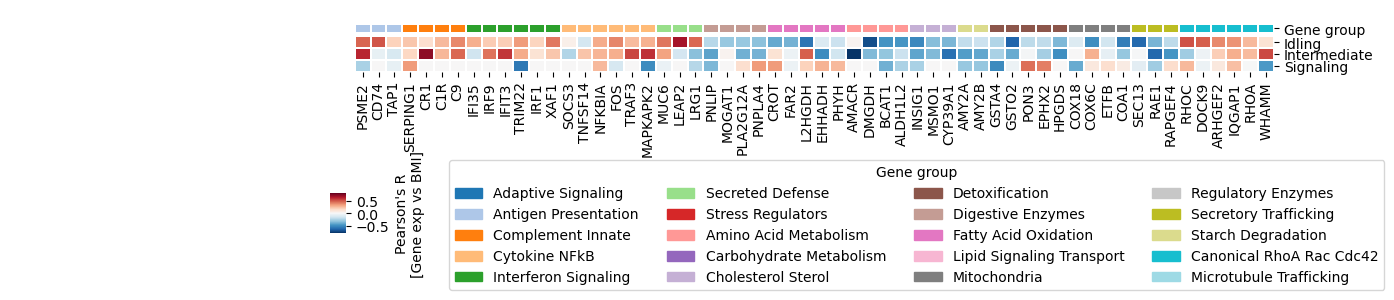

In [ ]:
import matplotlib.patches as mpatches
###-------------------------------plot-------------------------------###

# 1) Build the matrix as rows=cell types, cols=genes (DISPLAY transpose)
#    df_Rs_wV2 is genes x celltypes
acinar_df_plot = acinar_df_Rs_rF1.loc[acinar_ordered_genes].T   # shape: (cell types) x (genes)

# 2) Column color bars (because genes are now COLUMNS)
big_gene_dict = {
    "Immune": acinar_immune_gene_lists,
    "Metabolism": acinar_metabolism_gene_lists,
    "Rho_GTPases": acinar_rho_gene_lists,
}
gene_to_big, gene_to_sub = {}, {}
for bigcat, subdict in big_gene_dict.items():
    for subcat, genes in subdict.items():
        for g in genes:
            gene_to_big[g] = bigcat
            gene_to_sub[g] = subcat

# 3) Series aligned to gene columns
# col_big = pd.Series([gene_to_big.get(g, "Other") for g in acinar_df_plot.columns],
#                     index=acinar_df_plot.columns)
col_sub = pd.Series([gene_to_sub.get(g, "Other") for g in acinar_df_plot.columns],
                    index=acinar_df_plot.columns)

palette_big = {
    "Immune": "#e41a1c",
    "Metabolism": "#377eb8",
    "Rho_GTPases": "#4daf4a",
#     "Other": "lightgray",
}
# unique_subs = col_sub.unique()

col_colors = pd.DataFrame({
#     "Big Category": col_big.map(palette_big),
    "Gene group":  col_sub.map(palette_sub),
})

# 4) Plot (columns=genes), keep cell-type rows uncluttered
g = sns.clustermap(
    acinar_df_plot,
    row_cluster=False,             # or True if you want to cluster cell types
    col_cluster=False,             # we already ordered genes
    cmap="RdBu_r", center=0, vmin=-0.8, vmax=0.8,
    col_colors=col_colors,         # <-- column color bars now
    linewidths=0.3,
    figsize=(16, 0.8),               # wider than tall
    colors_ratio=(.05, 0.16),       # second value widens column color bars
    cbar_kws={"label": "Pearson's R\n[Gene exp vs BMI]"},
)

g.fig.subplots_adjust(left=0.18, right=0.97, bottom=0.22, top=1)
g.cax.set_position([0.38, -1.8, .01, .5])  # [left, bottom, width, height] in figure coordinates

# 5) Make room for x (gene) labels and keep row labels readable
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, ha="center")
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0, ha="left")

# 6) Optional: custom row (cell-type) labels
g.ax_heatmap.set_ylabel("")
g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_yticks([0.5, 1.5, 2.5])
g.ax_heatmap.set_yticklabels(['Idling', 'Intermediate', 'Signaling'])

# 7) Two separate legends (big & sub), placed under/left using figure transform
# big_patches = [mpatches.Patch(color=c, label=lab.replace('_', ' '))
#                for lab, c in palette_big.items()]
sub_patches = [mpatches.Patch(color=c, label=lab.replace('_', ' '))
               for lab, c in palette_sub.items()]

# leg1 = g.ax_col_dendrogram.legend(
#     handles=big_patches, title="Big category",
#     loc="upper left", bbox_to_anchor=(0.43, -0.2),
#     bbox_transform=g.fig.transFigure,
#     frameon=True,
# )
leg2 = g.ax_col_dendrogram.legend(
    handles=sub_patches, title="Gene group",
    loc="upper left", bbox_to_anchor=(0.45, -0.8),
    bbox_transform=g.fig.transFigure,
    frameon=True,  ncol=4
)
# g.ax_col_dendrogram.add_artist(leg1)  # keep both

g.savefig(
    f'../../figures/manuscript_figures/obese_rF1/Acinar_immune_meta_rho_pearson_r_vs_BMI_rF1_3csts.png',
    bbox_inches='tight', dpi=300
           )
g.savefig(
    f'../../figures/manuscript_figures/obese_rF1/Acinar_immune_meta_rho_pearson_r_vs_BMI_rF1_3csts.pdf',
    bbox_inches='tight', dpi=300
           )

/tmp/ipykernel_202310/1969376077.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap)
/tmp/ipykernel_202310/1969376077.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


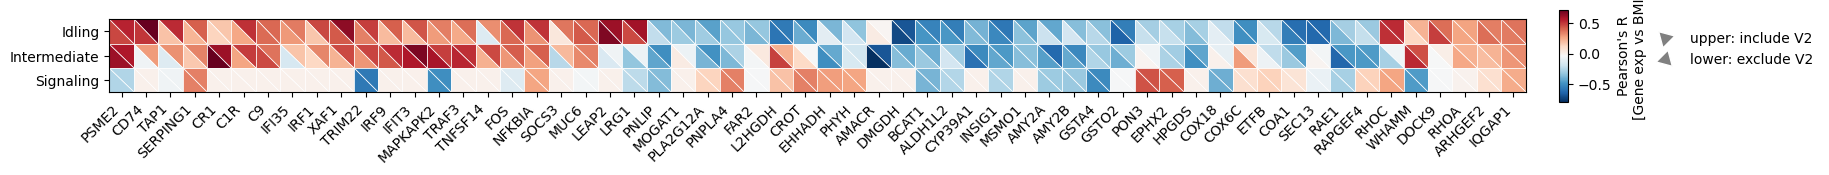

In [ ]:
fig = plot_split_heatmap(acinar_df_Rs_rF1.loc[acinar_ordered_genes], 
                         acinar_df_Rs_rF1_rV2.loc[acinar_ordered_genes], 
                         transpose=True,
                         exclude_sample='V2'
                         )['fig']

fig.savefig(
    f'../../figures/manuscript_figures/obese_rF1/Acinar_immune_meta_rho_pearson_r_vs_BMI_rF1_rV2_3csts.png',
    bbox_inches='tight', dpi=300
           )
fig.savefig(
    f'../../figures/manuscript_figures/obese_rF1/Acinar_immune_meta_rho_pearson_r_vs_BMI_rF1_rV2_3csts.pdf',
    bbox_inches='tight', dpi=300
           )

In [ ]:
adata_ductal_und = adata[
    (adata.obs['cell_type'] == 'Ductal') &
    (~ adata.obs['group'].isin(['T1D', 'T2D']))
].copy()

adata_ductal_und.obs['cell_subtype'].value_counts() * 100 / adata_ductal_und.obs.shape[0]

cell_subtype
Basal_ductal       62.037766
Inflam_ductal_1    18.882769
Inflam_ductal_2    18.151062
MUC5B+_ductal       0.928403
Name: count, dtype: float64

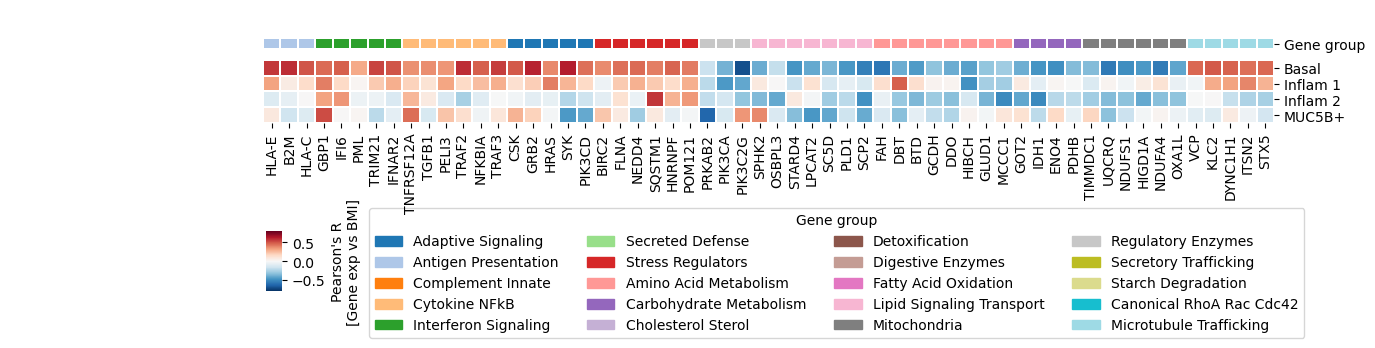

In [ ]:
###-------------------------------get acinar genes-------------------------------###
# combine these genes and show the pearson R's in cell type and cell subtypes
ductal_gene_lists = {
    cat: genes
    for gene_lists in [ductal_immune_gene_lists, ductal_metabolism_gene_lists, ductal_rho_gene_lists]
    for cat, genes in gene_lists.items()
}

ductal_unique_genes = list(
    set([g for gl in ductal_gene_lists.values() for g in gl])
)

cts_show = [
#     'Acinar', 'Basal_acinar', 'High_enzyme_acinar',
#     'Ductal', 
    'Basal_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2', 'MUC5B+_ductal'
          ]

ductal_df_Rs_wF1 = pd.DataFrame(index=ductal_unique_genes, columns=cts_show)
for ct in cts_show:
    ductal_df_Rs_wF1[ct] = pearsonr_dic['wV2', ct].loc[ductal_unique_genes]['r']
ductal_df_Rs_wF1 = ductal_df_Rs_wF1.fillna(0)

ductal_df_Rs_rF1 = pd.DataFrame(index=ductal_unique_genes, columns=cts_show)
for ct in cts_show:
    ductal_df_Rs_rF1[ct] = pearsonr_dic['rF1', ct].loc[ductal_unique_genes]['r']
ductal_df_Rs_rF1 = ductal_df_Rs_rF1.fillna(0)

ductal_df_Rs_rF1_rV2 = pd.DataFrame(index=ductal_unique_genes, columns=cts_show)
for ct in cts_show:
    ductal_df_Rs_rF1_rV2[ct] = pearsonr_dic['rF1_rV2', ct].loc[ductal_unique_genes]['r']
ductal_df_Rs_rF1_rV2 = ductal_df_Rs_rF1_rV2.fillna(0)

###-------------------------------plot-------------------------------###
# 0) Order genes (same as before)
ductal_ordered_genes = order_genes_by_hclust_per_category(
    ductal_df_Rs_wF1,                # genes x cell types
    ductal_gene_lists,        # or ductal_metabolism_gene_lists / ductal_immune_gene_lists
    metric="correlation",
    method="average",
)

# 1) Build the matrix as rows=cell types, cols=genes (DISPLAY transpose)
#    df_Rs_wV2 is genes x celltypes
ductal_df_plot = ductal_df_Rs_wF1.loc[ductal_ordered_genes].T   # shape: (cell types) x (genes)

# 2) Column color bars (because genes are now COLUMNS)
big_gene_dict = {
    "Immune": ductal_immune_gene_lists,
    "Metabolism": ductal_metabolism_gene_lists,
    "Rho_GTPases": ductal_rho_gene_lists,
}
gene_to_big, gene_to_sub = {}, {}
for bigcat, subdict in big_gene_dict.items():
    for subcat, genes in subdict.items():
        for g in genes:
            gene_to_big[g] = bigcat
            gene_to_sub[g] = subcat

# 3) Series aligned to gene columns
# col_big = pd.Series([gene_to_big.get(g, "Other") for g in ductal_df_plot.columns],
#                     index=df_plot.columns)
col_sub = pd.Series([gene_to_sub.get(g, "Other") for g in ductal_df_plot.columns],
                    index=ductal_df_plot.columns)

# palette_big = {
#     "Immune": "#e41a1c",
#     "Metabolism": "#377eb8",
#     "Rho_GTPases": "#4daf4a",
# #     "Other": "lightgray",
# }
# unique_subs = col_sub.unique()
# palette_sub = dict(zip(unique_subs, sns.color_palette("tab20", len(unique_subs))))

col_colors = pd.DataFrame({
#     "Big Category": col_big.map(palette_big),
    "Gene group":  col_sub.map(palette_sub),
})

# 4) Plot (columns=genes), keep cell-type rows uncluttered
g = sns.clustermap(
    ductal_df_plot,
    row_cluster=False,             # or True if you want to cluster cell types
    col_cluster=False,             # we already ordered genes
    cmap="RdBu_r", center=0, vmin=-0.8, vmax=0.8,
    col_colors=col_colors,         # <-- column color bars now
    linewidths=0.3,
    figsize=(16, 1.5),               # wider than tall
    colors_ratio=(.05, .12),       # second value widens column color bars
    cbar_kws={"label": "Pearson's R\n[Gene exp vs BMI]"},
)

g.fig.subplots_adjust(left=0.18, right=0.97, bottom=0.22, top=0.98)
g.cax.set_position([0.34, -0.9, .01, .4])  # [left, bottom, width, height] in figure coordinates

# 5) Make room for x (gene) labels and keep row labels readable
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, ha="center")
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0, ha="left")

# 6) Optional: custom row (cell-type) labels
g.ax_heatmap.set_ylabel("")
g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_yticks([0.5, 1.5, 2.5, 3.5])
g.ax_heatmap.set_yticklabels(['Basal', 'Inflam 1', 'Inflam 2', 'MUC5B+'])

# 7) Two separate legends (big & sub), placed under/left using figure transform
# big_patches = [mpatches.Patch(color=c, label=lab.replace('_', ' '))
#                for lab, c in palette_big.items()]
sub_patches = [mpatches.Patch(color=c, label=lab.replace('_', ' '))
               for lab, c in palette_sub.items()]

# leg1 = g.ax_col_dendrogram.legend(
#     handles=big_patches, title="Big category",
#     loc="upper left", bbox_to_anchor=(0.43, -0.2),
#     bbox_transform=g.fig.transFigure,
#     frameon=True,
# )
leg2 = g.ax_col_dendrogram.legend(
    handles=sub_patches, title="Gene group",
    loc="upper left", bbox_to_anchor=(0.4, -0.3),
    bbox_transform=g.fig.transFigure,
    frameon=True,  ncol=4
)
# g.ax_col_dendrogram.add_artist(leg1)  # keep both

g.savefig(
    f'../../figures/manuscript_figures/obese_rF1/Ductal_immune_meta_rho_pearson_r_vs_BMI_wV2.png',
    bbox_inches='tight', dpi=300
           )
g.savefig(
    f'../../figures/manuscript_figures/obese_rF1/Ductal_immune_meta_rho_pearson_r_vs_BMI_wV2.pdf',
    bbox_inches='tight', dpi=300
           )

/tmp/ipykernel_202310/1969376077.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap)
/tmp/ipykernel_202310/1969376077.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


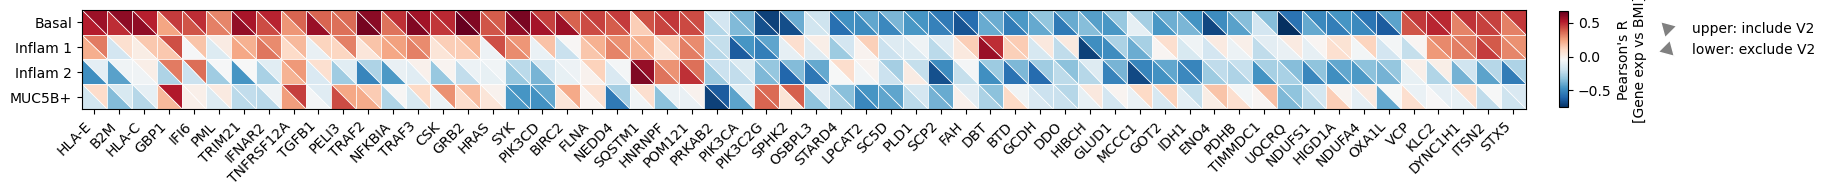

In [49]:
fig = plot_split_heatmap(ductal_df_Rs_wF1.loc[ductal_ordered_genes], 
                         ductal_df_Rs_rF1_rV2.loc[ductal_ordered_genes], 
                         transpose=True,
                         exclude_sample='V2'
                         )['fig']

fig.savefig(
    f'../../figures/manuscript_figures/obese_rF1/Ductal_immune_meta_rho_pearson_r_vs_BMI_rF1_rV2.png',
    bbox_inches='tight', dpi=300
           )
fig.savefig(
    f'../../figures/manuscript_figures/obese_rF1/Ductal_immune_meta_rho_pearson_r_vs_BMI_rF1_rV2.pdf',
    bbox_inches='tight', dpi=300
           )

# Supplementary figures

In [ ]:
res_path = '../../tables/pathway_analysis/lean_obese_f/results/'
fig_path = '../../figures/pathway_analysis/lean_obese_f/results/'

os.makedirs(res_path, exist_ok=True)
os.makedirs(fig_path, exist_ok=True)

## load results

In [ ]:
## load dresults - with sex as covariates
ann_lists = {
    'cell_type': [
    'Acinar', 
    'Endothelial', 
    'Ductal', 
    'Endocrine',
    'Immune',
    'Stellate',
    ],
    'cell_subtype1': [
    'α', 'β', 
    'Idling_acinar', 'Intermediate_acinar', 'Signaling_acinar', 
    'Basal_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2', 'MUC5B+_ductal',
    'Macrophages', 'Plasmablasts', 'T_cells', 'Mast_cells',
    'Arterial_ECs', 'Venous_ECs', 'Capillary_ECs', 'Lymphatic_ECs',
    'Activated_stellates', 'Quiescent_stellates', 
    ]  
}

data_methods = {
    'wo_m': {'DESeq': '', 'memento': ''},
    'w_m': {'DESeq': '_by_Sex', 'memento': '_by_sex'},
}

deseq_wom_path = '../../tables/DESeq/DESeq_results/lean_obese_f/full_data'
memento_wom_path = '../../tables/memento/results/lean_obese_f/'
deseq_wm_path = '../../tables/DESeq/DESeq_results/obese_rF1/full_data'
memento_wm_path = '../../tables/memento/results/obese_rF1/'
paths = {
    'wo_m': {'DESeq': deseq_wom_path, 'memento': memento_wom_path},
    'w_m': {'DESeq': deseq_wm_path, 'memento': memento_wm_path},
}

deseq_other_path = '../../tables/DESeq/DESeq_results/obese_rF1/full_data'
memento_other_path = '../../tables/memento/results/obese_rF1/'

ref_group = 'ND-Lean'
groups = ['ND-Obese', 'Pre-T2D', 'T2D'] 
DEG_res = {}

for dt, methods in data_methods.items():
    for method, covariate in methods.items():
        for group in groups:
            if group == 'ND-Obese':
                for ct_obs, cts in ann_lists.items():
                    for ct in cts:
                        DEG_res[(dt, method, covariate, group, ct)] = (
                            load_deseq_res(paths[dt]['DESeq'], ct_obs, ct, group, ref_group, covariate) 
                            if method == 'DESeq' 
                            else load_mm_res(paths[dt]['memento'], ct_obs, ct, group, covariate)
                        )
            else:
                for ct_obs, cts in ann_lists.items():
                    for ct in cts:
                        DEG_res[('w_m', method, covariate, group, ct)] = (
                            load_deseq_res(deseq_other_path, ct_obs, ct, group, ref_group, covariate) 
                            if method == 'DESeq' 
                            else load_mm_res(memento_other_path, ct_obs, ct, group, covariate)
                        )                        

## DEG numbers

In [ ]:
# get pathways
from itertools import chain
import gseapy as gp

if False:
    memento_log2FC = 1
    deseq_de_log2FC = 1
    memento_de_pval_adj = 0.05

    # save pathway number information
    DEG_numbers = {}
    ref_group = 'ND-Lean'
    # groups = ['ND-Obese', 'Pre-T2D', 'T2D']
    group = 'ND-Obese'
    data_methods = {
        'wo_m': {'DESeq': '', 'memento': ''},
        'w_m': {'DESeq': '_by_Sex', 'memento': '_by_sex'},
    }

    for dt, methods in data_methods.items():
        for ct in list(chain.from_iterable(ann_lists.values())):
            deseq_df = DEG_res[(dt, 'DESeq', methods['DESeq'], group, ct)]
            memento_df = DEG_res[(dt, 'memento', methods['memento'], group, ct)]
            
            if deseq_df is None or memento_df is None: # avoid cell subtypes that couldn't get DEGs
                DEG_numbers[(ct, dt, 'Up')] = 0
                DEG_numbers[(ct, dt, 'Down')] = 0
                
            else:
                # merge DESeq and memento results
                common_genes = list(set(memento_df.index) & set(deseq_df.index))
                compare_df = pd.concat([memento_df.loc[common_genes], deseq_df.loc[common_genes]], axis=1)

                up_df = compare_df[
                    (((compare_df['memento_log2FC'] > memento_log2FC) 
                        & (compare_df['deseq_de_log2FC'] > 0))
                    | 
                    ((compare_df['deseq_de_log2FC'] > deseq_de_log2FC)
                    & (compare_df['memento_log2FC'] > 0))) 
                    & (compare_df['memento_de_pval_adj'] < memento_de_pval_adj)
                ]

                down_df = compare_df[
                    (((compare_df['memento_log2FC'] < - memento_log2FC) 
                        & (compare_df['deseq_de_log2FC'] < 0))
                    | 
                    ((compare_df['deseq_de_log2FC'] < - deseq_de_log2FC)
                    & (compare_df['memento_log2FC'] < 0)))
                    & (compare_df['memento_de_pval_adj'] < memento_de_pval_adj)
                ]

                # save DEG numbers
                DEG_numbers[(ct, dt, 'Up')] = up_df.shape[0]
                DEG_numbers[(ct, dt, 'Down')] = - down_df.shape[0]

    DEG_numbers = pd.DataFrame.from_dict(DEG_numbers, orient='index')
    DEG_numbers.columns = ['#DEG']
    DEG_numbers.index = pd.MultiIndex.from_tuples(DEG_numbers.index, names=['cell_type', 'data_type', 'type'])
    DEG_numbers = DEG_numbers.reset_index()
    DEG_numbers.to_csv(f'../../figures/manuscript_figures/lean_obese_f/lean_obese_w_wo_m_DEG_numbers.tsv', sep='\t', index=False)

In [ ]:
# DEG numbers and pathway numbers 
DEG_numbers = pd.read_csv(
    f'../../figures/manuscript_figures/lean_obese_f/lean_obese_w_wo_m_DEG_numbers.tsv',
    sep='\t')

/tmp/ipykernel_571790/285788825.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  up_DEG_n['cell_type'] = up_DEG_n['cell_type'].astype('category')
/tmp/ipykernel_571790/285788825.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  up_DEG_n['cell_type'] = up_DEG_n['cell_type'].cat.reorder_categories(cts)
/tmp/ipykernel_571790/285788825.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

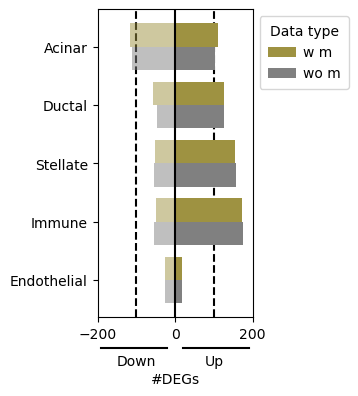

In [ ]:
cts = ['Acinar', 'Ductal', 'Stellate', 'Immune', 'Endothelial']
hue_order=['w_m', 'wo_m']
palette=[group_colors['ND-Obese'], 'grey']

fig = plot_number_by_group(DEG_numbers, cts, 200, hue_order=hue_order, palette=palette, figsize=[2, 3])['fig']

fig.savefig(
    os.path.join('../../figures/manuscript_figures/lean_obese_f/', 'DEG_numbers_by_group.png'), 
    dpi=300, bbox_inches='tight'
)
fig.savefig(
    os.path.join('../../figures/manuscript_figures/lean_obese_f/', 'DEG_numbers_by_group.pdf'), 
    dpi=300, bbox_inches='tight'
)

## Acinar cells (ND-Obese vs T2D)

In [ ]:
ct_obs = 'cell_type'
ct = 'Acinar'
memento_log2FC = 1
deseq_de_log2FC = 1
memento_de_pval_adj = 0.05

group_covs = {
    'ND-Obese': {'DESeq': '', 'memento': ''}, 
    'T2D': {'DESeq': '_by_Sex', 'memento': '_by_sex'}
    }
dd_type = {
    'ND-Obese': 'wo_m',
    'T2D': 'w_m',
}

compare_dfs = {}
for group, covs in group_covs.items():
    deseq_df = DEG_res[(dd_type[group], 'DESeq', covs['DESeq'], group, ct)]
    memento_df = DEG_res[(dd_type[group], 'memento', covs['memento'], group, ct)]
    # merge DESeq and memento results
    common_genes = list(set(memento_df.index) & set(deseq_df.index))
    compare_df = pd.concat([memento_df.loc[common_genes], deseq_df.loc[common_genes]], axis=1)

    compare_df['Group'] = 'ns'
    # for groups other than Pre-T2D, get DEGs based on both memento and DESeq
    compare_df.loc[
        (((compare_df['memento_log2FC'] > memento_log2FC) 
            & (compare_df['deseq_de_log2FC'] > 0))
        | 
        ((compare_df['deseq_de_log2FC'] > deseq_de_log2FC)
        & (compare_df['memento_log2FC'] > 0))) 
        & (compare_df['memento_de_pval_adj'] < memento_de_pval_adj),
        'Group'] = 'Up'

    compare_df.loc[
        (((compare_df['memento_log2FC'] < - memento_log2FC) 
            & (compare_df['deseq_de_log2FC'] < 0))
        | 
        ((compare_df['deseq_de_log2FC'] < - deseq_de_log2FC)
        & (compare_df['memento_log2FC'] < 0)))
        & (compare_df['memento_de_pval_adj'] < memento_de_pval_adj),
        'Group'] = 'Down'
    compare_dfs[group] = compare_df

# get family genes
sig_genes = {
    group: compare_dfs[group][compare_dfs[group]['Group'] != 'ns'].index.tolist()
    for group in ['ND-Obese', 'T2D']
}

up_sig_genes = {
    group: compare_dfs[group][compare_dfs[group]['Group'] == 'Up'].index.tolist()
    for group in ['ND-Obese', 'T2D']
}

down_sig_genes = {
    group: compare_dfs[group][compare_dfs[group]['Group'] == 'Down'].index.tolist()
    for group in ['ND-Obese', 'T2D']
}

all_genes = list(set(gene for genes in sig_genes.values() for gene in genes)) # all DEGs from each group vs lean

pseudo_sum = '../../tables/DESeq/pseudo_bulk_sum/lean_obese_f/'
# the median pseudo-bulk expression of these DEGs in every group
pseu_bu_median = pd.DataFrame(index=all_genes, columns=['ND-Lean', 'ND-Obese', 'T2D'])
pseudo_bulk_exp = pd.read_csv(
    os.path.join(pseudo_sum, f'{ct_obs}_{ct}_pseudo_bulk_sum_counts.tsv'), 
    sep='\t', index_col=0)
pseudo_bulk_exp_log2cpm = np.log2(pseudo_bulk_exp * 1e6 / pseudo_bulk_exp.sum() + 1)

for col in pseu_bu_median.columns:    
    donors = list(set(group_donor_dict[col]) & set(pseudo_bulk_exp_log2cpm.columns))
    pseu_bu_median[col] = pseudo_bulk_exp_log2cpm[donors].median(axis=1).loc[all_genes]

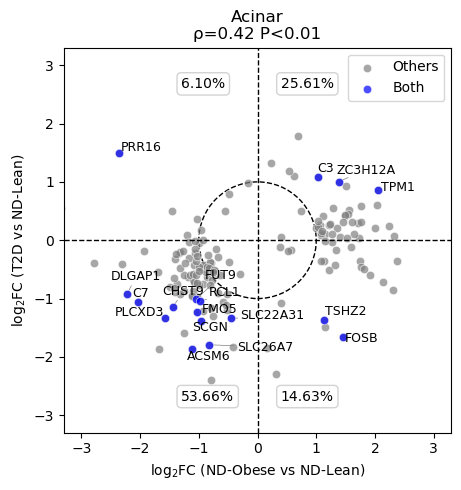

In [ ]:
from adjustText import adjust_text
from scipy.stats import spearmanr

# group genes
scatter_genes = list(
    set(set(sig_genes['ND-Obese']) | set(set(sig_genes['T2D'])))
    & set(protein_coding_genes)
    & set(compare_dfs['ND-Obese'].index)
    & set(compare_dfs['T2D'].index)
                    )
log2FC_df = pd.DataFrame(index=scatter_genes, columns=['ND-Obese', 'T2D', 'Group'])
for group in ['ND-Obese', 'T2D']:
    log2FC_df[group] = compare_dfs[group].loc[scatter_genes, 'memento_log2FC']  # 'deseq_pseudo_bulk_log2FC'
log2FC_df['Group'] = 'Others'
log2FC_df.loc[log2FC_df.index.isin(
    list(set(sig_genes['ND-Obese']) & set(sig_genes['T2D']))), 'Group'] = 'Both'

log2FC_df.to_csv(
    os.path.join('../../tables/pathway_analysis/', f'{ct}_obese_T2D_sig_genes_memento_log2FC_lean_obese_f.tsv'), sep='\t')

## plot the location of same genes as with donor F1
log2FC_df_org = pd.read_csv(
    os.path.join('../../tables/pathway_analysis/', f'{ct}_obese_T2D_sig_genes_memento_log2FC_wV2.tsv'), 
    sep='\t', index_col=0)

# plotting
fig, ax = plt.subplots(figsize=[5, 5])
sns.scatterplot(log2FC_df, 
                x='ND-Obese', y='T2D', 
                color='gray',
                label='Others',
                alpha=0.7)

# add auxiliary lines
circle = plt.Circle((0, 0), 1, color='k', fill=False, ls='--', zorder=0, lw=1)
ax.add_patch(circle)
for i in [0,]:
    ax.axvline(i, ls='--', lw=1, c='k')
for i in [0]:
    ax.axhline(i, ls='--', lw=1, c='k')

# figure settings
ax.set_xlim([-3.3, 3.3])
ax.set_ylim([-3.3, 3.3])
# ax.set_title(ct)
ax.set_xlabel(f'log$_2$FC (ND-Obese vs ND-Lean)') # memento
ax.set_ylabel(f'log$_2$FC (T2D vs ND-Lean)')
ax.legend(bbox_to_anchor=[0, 1], title='Group',  loc='upper left')

# Annotate selected genes
genes_to_annotate = log2FC_df_org[log2FC_df_org['Group'] == 'Both'].index.tolist()
genes_to_annotate = list(set(genes_to_annotate) & set(log2FC_df.index)) # make sure the gene exist
texts = []
for gene in genes_to_annotate:
    gx = log2FC_df.loc[gene]['ND-Obese']
    gy = log2FC_df.loc[gene]['T2D']
    texts.append(ax.text(gx, gy, gene, fontsize=9))
# Adjust text to avoid overlaps
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

sns.scatterplot(
    log2FC_df.loc[genes_to_annotate], 
    x='ND-Obese', y='T2D', 
    color='blue',
    label='Both',
    alpha=0.7)

# add text
annotate_df = log2FC_df.copy()
rho = spearmanr(annotate_df['ND-Obese'], annotate_df['T2D']).statistic
P = spearmanr(annotate_df['ND-Obese'], annotate_df['T2D']).pvalue
text = f'ρ={rho:.2f} P={P:.2f}' if P > 0.01 else f'ρ={rho:.2f} P<0.01'
# ax.text(0, 2.8, text, va='top', ha='center')
ax.set_title(f'{ct}\n{text}')
# quadrant 1
pct1 = 100 * (
    (annotate_df['ND-Obese'] > 0)
    & (annotate_df['T2D'] > 0)
).sum() / annotate_df.shape[0]
ax.text(1.3, 2.8, f'{pct1:.2f}%', va='top', ha='right', 
        bbox=dict(
        facecolor='white',          # background color
        edgecolor='lightgray',          # border color
        boxstyle='round,pad=0.3',   # rounded box, with padding
        linewidth=1                 # border width
    ))
# quadrant 2
pct2 = 100 * (
    (annotate_df['ND-Obese'] < 0)
    & (annotate_df['T2D'] > 0)
).sum() / annotate_df.shape[0]
ax.text(-1.3, 2.8, f'{pct2:.2f}%', va='top', ha='left',
        bbox=dict(
        facecolor='white',          # background color
        edgecolor='lightgray',          # border color
        boxstyle='round,pad=0.3',   # rounded box, with padding
        linewidth=1                 # border width
    ))
# quadrant 3
pct3 = 100 * (
    (annotate_df['ND-Obese'] < 0)
    & (annotate_df['T2D'] < 0)
).sum() / annotate_df.shape[0]
ax.text(-1.3, -2.8, f'{pct3:.2f}%', va='bottom', ha='left',
        bbox=dict(
        facecolor='white',          # background color
        edgecolor='lightgray',          # border color
        boxstyle='round,pad=0.3',   # rounded box, with padding
        linewidth=1                 # border width
    ))
# quadrant 4
pct4 = 100 * (
    (annotate_df['ND-Obese'] > 0)
    & (annotate_df['T2D'] < 0)
).sum() / annotate_df.shape[0]
ax.text(1.3, -2.8, f'{pct4:.2f}%', va='bottom', ha='right',
        bbox=dict(
        facecolor='white',          # background color
        edgecolor='lightgray',          # border color
        boxstyle='round,pad=0.3',   # rounded box, with padding
        linewidth=1                 # border width
    ))

# save figure
fig.savefig(
    os.path.join(
        f'../../figures/manuscript_figures/lean_obese_f/', f'{ct}_scatter_sig_DEGs_show_original_genes.png'), 
    dpi=300, bbox_inches='tight'
)
fig.savefig(
    os.path.join(
        f'../../figures/manuscript_figures/lean_obese_f/', f'{ct}_scatter_sig_DEGs_show_original_genes.pdf'), 
    dpi=300, bbox_inches='tight'
)

## Ductal cells (ND-Obese vs T2D)

In [ ]:
ct_obs = 'cell_type'
ct = 'Ductal'
memento_log2FC = 1
deseq_de_log2FC = 1
memento_de_pval_adj = 0.05

group_covs = {
    'ND-Obese': {'DESeq': '', 'memento': ''}, 
    'T2D': {'DESeq': '_by_Sex', 'memento': '_by_sex'}
    }
dd_type = {
    'ND-Obese': 'wo_m',
    'T2D': 'w_m',
}

compare_dfs = {}
for group, covs in group_covs.items():
    deseq_df = DEG_res[(dd_type[group], 'DESeq', covs['DESeq'], group, ct)]
    memento_df = DEG_res[(dd_type[group], 'memento', covs['memento'], group, ct)]
    # merge DESeq and memento results
    common_genes = list(set(memento_df.index) & set(deseq_df.index))
    compare_df = pd.concat([memento_df.loc[common_genes], deseq_df.loc[common_genes]], axis=1)

    compare_df['Group'] = 'ns'
    # for groups other than Pre-T2D, get DEGs based on both memento and DESeq
    compare_df.loc[
        (((compare_df['memento_log2FC'] > memento_log2FC) 
            & (compare_df['deseq_de_log2FC'] > 0))
        | 
        ((compare_df['deseq_de_log2FC'] > deseq_de_log2FC)
        & (compare_df['memento_log2FC'] > 0))) 
        & (compare_df['memento_de_pval_adj'] < memento_de_pval_adj),
        'Group'] = 'Up'

    compare_df.loc[
        (((compare_df['memento_log2FC'] < - memento_log2FC) 
            & (compare_df['deseq_de_log2FC'] < 0))
        | 
        ((compare_df['deseq_de_log2FC'] < - deseq_de_log2FC)
        & (compare_df['memento_log2FC'] < 0)))
        & (compare_df['memento_de_pval_adj'] < memento_de_pval_adj),
        'Group'] = 'Down'
    compare_dfs[group] = compare_df

# get family genes
sig_genes = {
    group: compare_dfs[group][compare_dfs[group]['Group'] != 'ns'].index.tolist()
    for group in ['ND-Obese', 'T2D']
}

up_sig_genes = {
    group: compare_dfs[group][compare_dfs[group]['Group'] == 'Up'].index.tolist()
    for group in ['ND-Obese', 'T2D']
}

down_sig_genes = {
    group: compare_dfs[group][compare_dfs[group]['Group'] == 'Down'].index.tolist()
    for group in ['ND-Obese', 'T2D']
}

all_genes = list(set(gene for genes in sig_genes.values() for gene in genes)) # all DEGs from each group vs lean

pseudo_sum = '../../tables/DESeq/pseudo_bulk_sum/lean_obese_f/'
# the median pseudo-bulk expression of these DEGs in every group
pseu_bu_median = pd.DataFrame(index=all_genes, columns=['ND-Lean', 'ND-Obese', 'T2D'])
pseudo_bulk_exp = pd.read_csv(
    os.path.join(pseudo_sum, f'{ct_obs}_{ct}_pseudo_bulk_sum_counts.tsv'), 
    sep='\t', index_col=0)
pseudo_bulk_exp_log2cpm = np.log2(pseudo_bulk_exp * 1e6 / pseudo_bulk_exp.sum() + 1)

for col in pseu_bu_median.columns:    
    donors = list(set(group_donor_dict[col]) & set(pseudo_bulk_exp_log2cpm.columns))
    pseu_bu_median[col] = pseudo_bulk_exp_log2cpm[donors].median(axis=1).loc[all_genes]

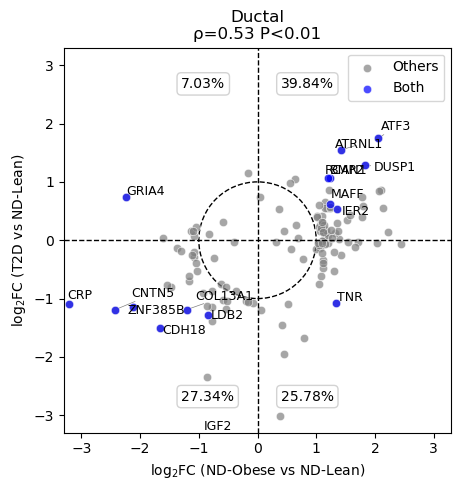

In [ ]:
from adjustText import adjust_text
from scipy.stats import spearmanr

# group genes
scatter_genes = list(
    set(set(sig_genes['ND-Obese']) | set(set(sig_genes['T2D'])))
    & set(protein_coding_genes)
    & set(compare_dfs['ND-Obese'].index)
    & set(compare_dfs['T2D'].index)
                    )
log2FC_df = pd.DataFrame(index=scatter_genes, columns=['ND-Obese', 'T2D', 'Group'])
for group in ['ND-Obese', 'T2D']:
    log2FC_df[group] = compare_dfs[group].loc[scatter_genes, 'memento_log2FC']  # 'deseq_pseudo_bulk_log2FC'
log2FC_df['Group'] = 'Others'
log2FC_df.loc[log2FC_df.index.isin(
    list(set(sig_genes['ND-Obese']) & set(sig_genes['T2D']))), 'Group'] = 'Both'

log2FC_df.to_csv(
    os.path.join('../../tables/pathway_analysis/', f'{ct}_obese_T2D_sig_genes_memento_log2FC_lean_obese_f.tsv'), sep='\t')

## plot the location of same genes as with donor F1
log2FC_df_org = pd.read_csv(
    os.path.join('../../tables/pathway_analysis/', f'{ct}_obese_T2D_sig_genes_memento_log2FC_wV2.tsv'), 
    sep='\t', index_col=0)

# plotting
fig, ax = plt.subplots(figsize=[5, 5])
sns.scatterplot(log2FC_df, 
                x='ND-Obese', y='T2D', 
                color='gray',
                label='Others',
                alpha=0.7)

# add auxiliary lines
circle = plt.Circle((0, 0), 1, color='k', fill=False, ls='--', zorder=0, lw=1)
ax.add_patch(circle)
for i in [0,]:
    ax.axvline(i, ls='--', lw=1, c='k')
for i in [0]:
    ax.axhline(i, ls='--', lw=1, c='k')

# figure settings
ax.set_xlim([-3.3, 3.3])
ax.set_ylim([-3.3, 3.3])
# ax.set_title(ct)
ax.set_xlabel(f'log$_2$FC (ND-Obese vs ND-Lean)') # memento
ax.set_ylabel(f'log$_2$FC (T2D vs ND-Lean)')
ax.legend(bbox_to_anchor=[0, 1], title='Group',  loc='upper left')

# Annotate selected genes
genes_to_annotate = log2FC_df_org[log2FC_df_org['Group'] == 'Both'].index.tolist()
genes_to_annotate = list(set(genes_to_annotate) & set(log2FC_df.index)) # make sure the gene exist
texts = []
for gene in genes_to_annotate:
    gx = log2FC_df.loc[gene]['ND-Obese']
    gy = log2FC_df.loc[gene]['T2D']
    texts.append(ax.text(gx, gy, gene, fontsize=9))
# Adjust text to avoid overlaps
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

sns.scatterplot(
    log2FC_df.loc[genes_to_annotate], 
    x='ND-Obese', y='T2D', 
    color='blue',
    label='Both',
    alpha=0.7)

# add text
annotate_df = log2FC_df.copy()
rho = spearmanr(annotate_df['ND-Obese'], annotate_df['T2D']).statistic
P = spearmanr(annotate_df['ND-Obese'], annotate_df['T2D']).pvalue
text = f'ρ={rho:.2f} P={P:.2f}' if P > 0.01 else f'ρ={rho:.2f} P<0.01'
# ax.text(0, 2.8, text, va='top', ha='center')
ax.set_title(f'{ct}\n{text}')
# quadrant 1
pct1 = 100 * (
    (annotate_df['ND-Obese'] > 0)
    & (annotate_df['T2D'] > 0)
).sum() / annotate_df.shape[0]
ax.text(1.3, 2.8, f'{pct1:.2f}%', va='top', ha='right', 
        bbox=dict(
        facecolor='white',          # background color
        edgecolor='lightgray',          # border color
        boxstyle='round,pad=0.3',   # rounded box, with padding
        linewidth=1                 # border width
    ))
# quadrant 2
pct2 = 100 * (
    (annotate_df['ND-Obese'] < 0)
    & (annotate_df['T2D'] > 0)
).sum() / annotate_df.shape[0]
ax.text(-1.3, 2.8, f'{pct2:.2f}%', va='top', ha='left',
        bbox=dict(
        facecolor='white',          # background color
        edgecolor='lightgray',          # border color
        boxstyle='round,pad=0.3',   # rounded box, with padding
        linewidth=1                 # border width
    ))
# quadrant 3
pct3 = 100 * (
    (annotate_df['ND-Obese'] < 0)
    & (annotate_df['T2D'] < 0)
).sum() / annotate_df.shape[0]
ax.text(-1.3, -2.8, f'{pct3:.2f}%', va='bottom', ha='left',
        bbox=dict(
        facecolor='white',          # background color
        edgecolor='lightgray',          # border color
        boxstyle='round,pad=0.3',   # rounded box, with padding
        linewidth=1                 # border width
    ))
# quadrant 4
pct4 = 100 * (
    (annotate_df['ND-Obese'] > 0)
    & (annotate_df['T2D'] < 0)
).sum() / annotate_df.shape[0]
ax.text(1.3, -2.8, f'{pct4:.2f}%', va='bottom', ha='right',
        bbox=dict(
        facecolor='white',          # background color
        edgecolor='lightgray',          # border color
        boxstyle='round,pad=0.3',   # rounded box, with padding
        linewidth=1                 # border width
    ))

# save figure
fig.savefig(
    os.path.join(
        f'../../figures/manuscript_figures/lean_obese_f/', f'{ct}_scatter_sig_DEGs_show_original_genes.png'), 
    dpi=300, bbox_inches='tight'
)
fig.savefig(
    os.path.join(
        f'../../figures/manuscript_figures/lean_obese_f/', f'{ct}_scatter_sig_DEGs_show_original_genes.pdf'), 
    dpi=300, bbox_inches='tight'
)

## Enrichment score of immune genes in different cell types (ND-Lean vs ND-Obese/T2D)

In [ ]:
adata_tmp = adata[
    adata.obs['group'].isin(['ND-Lean', 'ND-Obese']) &
    (adata.obs['Sex'] != 'm')
].copy()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Acinar_ND-Lean vs. Acinar_ND-Obese: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:0.000e+00 U_stat=1.912e+07
Ductal_ND-Lean vs. Ductal_ND-Obese: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:3.458e-92 U_stat=4.256e+06
Stellate_ND-Lean vs. Stellate_ND-Obese: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.087e-12 U_stat=4.732e+04
Immune_ND-Lean vs. Immune_ND-Obese: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:3.831e-22 U_stat=1.058e+04


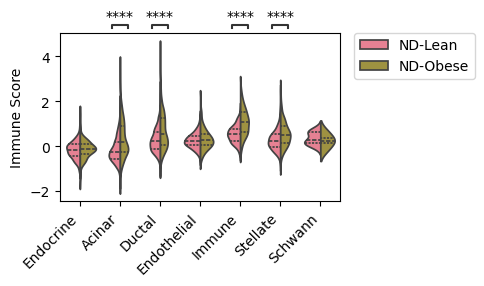

In [ ]:
# ND-Lean without male donors
fig = plot_immune_score(adata_tmp, ['ND-Lean', 'ND-Obese'])

# save figure
fig.savefig(
    os.path.join(
        f'../../figures/manuscript_figures/lean_obese_f/', 
        f'immune_score_obese_vs_lean_by_cell_type_only_female.png'), 
    dpi=300, bbox_inches='tight'
)
fig.savefig(
    os.path.join(
        f'../../figures/manuscript_figures/lean_obese_f/', 
        f'immune_score_obese_vs_lean_by_cell_type_only_female.pdf'), 
    dpi=300, bbox_inches='tight'
)

## Pearson analysis between gene expression and BMI (without male)

### computation

In [ ]:
pseudo_sum = '../../tables/DESeq/pseudo_bulk_sum/lean_obese_f/'
pseudo_bulk_exp = pd.read_csv(
        os.path.join(pseudo_sum  , f'{ct_obs}_{ct}_pseudo_bulk_sum_counts.tsv'), 
        sep='\t', index_col=0)

In [ ]:
ct_obs = 'cell_type'
fea = 'BMI'
method = 'pearsonr'
pct_threshold = 0.7
topn = 300
gene_sets = ['GO_Biological_Process_2023', 'Reactome_Pathways_2024']

##----------------------------------## all cells together
ct = 'all_cells'
#### load feature information
groups = ['ND-Lean', 'ND-Obese', 'Pre-T2D']
adata_tmp = adata[adata.obs['group'].isin(groups) & (adata.obs['Sex'] != 'm')].copy()
parse_donors = adata_tmp.obs['sample'].unique().tolist()
fea_donors_all = metadata.loc[parse_donors][metadata.loc[parse_donors]['group'].isin(groups)][[fea]].dropna().index.to_list()
feas = metadata.loc[fea_donors_all][fea]

#### load expression data
pseudo_sum = '../../tables/DESeq/pseudo_bulk_sum/lean_obese_f/'
pseudo_bulk_exp = pd.read_csv(
        os.path.join(pseudo_sum  , f'{ct_obs}_{ct}_pseudo_bulk_sum_counts.tsv'), 
        sep='\t', index_col=0)
pseudo_bulk_exp_log2cpm = np.log2(pseudo_bulk_exp * 1e6 / pseudo_bulk_exp.sum() + 1)
gene_exps = pseudo_bulk_exp_log2cpm[fea_donors_all].copy()

#### spearman analysis for all cells
y = np.asarray(feas, dtype=float)    # (n_samples,)
X = gene_exps.T.values.astype(float) # (n_samples, n_genes)  transpose once

all_corr = pearson_corr(X, y, gene_exps) # --> direct function for spearman analysis
all_corr['median_log2cpm'] = gene_exps.median(axis=1).loc[all_corr.index]
all_corr['n_exp'] = (gene_exps > 0).sum(axis=1).loc[all_corr.index]
all_corr['pct_exp'] = all_corr['n_exp'] / len(fea_donors_all)
outpath = f'../../figures/manuscript_figures/lean_obese_f/correlation/{fea}/{method}/{ct}_{method}_{fea}_exp_rm.tsv'

with open(outpath, "w") as f:
    f.write(f"# {len(groups)} groups used: " + ",".join(groups) + "\n")
    f.write(f"# all donors included\n")
    f.write(f"# {len(fea_donors_all)} donors used: " + ",".join(fea_donors_all) + "\n")
    f.write("# pseudo-bulk log2cpm is used\n")
    f.write(f"# {method} analysis\n")
    all_corr.to_csv(f, sep="\t")

#### filter out genes
all_corr = all_corr[(all_corr['pct_exp'] > pct_threshold) & (all_corr.index.isin(protein_coding_genes))].copy()

#### pathway analysis
pos_genes = all_corr.head(topn).index.tolist()
pos_pths = enrichr_pth(pos_genes, gene_sets, n_entities=1, fig_FDR=0.1)
pos_pths.to_csv(
    f'../../figures/manuscript_figures/lean_obese_f/correlation/{fea}/{method}/{ct}_top{topn}_{method}_pos_pathway_analysis_rm.tsv', 
    sep='\t', index=False)

neg_genes = all_corr.tail(topn).index.tolist()
neg_pths = enrichr_pth(neg_genes, gene_sets, n_entities=1, fig_FDR=0.1)
neg_pths.to_csv(
    f'../../figures/manuscript_figures/lean_obese_f/correlation/{fea}/{method}/{ct}_top{topn}_{method}_neg_pathway_analysis_rm.tsv', 
    sep='\t', index=False)

##----------------------------------## each celltype
nfold = 1.1
rho_threshold = 0.6
cts = ['Acinar', 'Ductal', 'Endocrine', 'Endothelial', 'Immune', 'Stellate']

ct_n_thresholds = {
    'Acinar': 105, 'Ductal': 50, 'Endocrine': 20, 'Endothelial': 10, 'Immune': 10, 'Stellate': 10, 'Schwann': 10
}

for ct in cts:
    #### basic information for calculating and plotting
    ct_numbers = adata_tmp.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
    fea_donors = ct_numbers.loc[ct_numbers > ct_n_thresholds[ct]].index.tolist()
    feas = metadata.loc[fea_donors][fea]

    pre_fea_donors = metadata.loc[fea_donors][metadata.loc[fea_donors]['group'].isin(['Pre-T2D'])][[fea]].dropna().index.to_list()
    pre_feas = metadata.loc[pre_fea_donors][fea]

    pseudo_bulk_exp = pd.read_csv(
            os.path.join(pseudo_sum  , f'{ct_obs}_{ct}_pseudo_bulk_sum_counts.tsv'), 
            sep='\t', index_col=0)
    pseudo_bulk_exp_log2cpm = np.log2(pseudo_bulk_exp * 1e6 / pseudo_bulk_exp.sum() + 1)

    gene_exps = pseudo_bulk_exp_log2cpm[fea_donors].copy()
    pre_gene_exps = pseudo_bulk_exp_log2cpm[pre_fea_donors].copy()
    
    #### pearsonr analysis
    y = np.asarray(feas, dtype=float)        # (n_samples,)
    X = gene_exps.T.values.astype(float)     # (n_samples, n_genes)  transpose once
    
    ct_corr = pearson_corr(X, y, gene_exps)
    ct_corr['median_log2cpm'] = gene_exps.median(axis=1).loc[ct_corr.index]
    ct_corr['n_exp'] = (gene_exps > 0).sum(axis=1).loc[ct_corr.index]
    ct_corr['pct_exp'] = ct_corr['n_exp'] / len(fea_donors)
    outpath = f'../../figures/manuscript_figures/lean_obese_f/correlation/{fea}/{method}/{ct}_{method}_{fea}_exp_rm.tsv'
    
    with open(outpath, "w") as f:
        f.write(f"# {len(groups)} groups used: " + ",".join(groups) + "\n")
        f.write(f"# donors with <= {ct_n_thresholds[ct]} {ct} are filtered out\n")
        f.write(f"# {len(fea_donors)} donors used: " + ",".join(fea_donors) + "\n")
        f.write("# pseudo-bulk log2cpm is used\n")
        f.write(f"# {method} analysis\n")
        ct_corr.to_csv(f, sep="\t")
    
    #### filter out genes
    ct_corr = ct_corr[(ct_corr['pct_exp'] > pct_threshold) & (ct_corr.index.isin(protein_coding_genes))].copy()
    if ct_corr.shape[0] < topn:
        print(f'{ct}: not enough genes for GSEA')
        continue
    else:
        #### pathway analysis of this cell type
        ct_pos_genes = ct_corr[ct_corr['r'] > 0].head(topn).index.tolist()
        ct_pos_pths = enrichr_pth(ct_pos_genes, gene_sets, n_entities=1, fig_FDR=0.1)
        ct_pos_pths.to_csv(
            f'../../figures/manuscript_figures/lean_obese_f/correlation/{fea}/{method}/{ct}_{method}_top{topn}_genes_pos_pathway_analysis_rm.tsv', 
            sep='\t', index=False)

        ct_neg_genes = ct_corr[ct_corr['r'] < 0].tail(topn).index.tolist()
        ct_neg_pths = enrichr_pth(ct_neg_genes, gene_sets, n_entities=1, fig_FDR=0.1)
        ct_neg_pths.to_csv(
            f'../../figures/manuscript_figures/lean_obese_f/correlation/{fea}/{method}/{ct}_{method}_top{topn}_genes_neg_pathway_analysis_rm.tsv', 
            sep='\t', index=False)

/tmp/ipykernel_4697/1604855450.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata_tmp.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_4697/1604855450.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata_tmp.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_4697/1604855450.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt t

In [ ]:
##### for cell subtypes
cst_obs = 'cell_subtype1'
fea = 'BMI'
method = 'pearsonr'
pct_threshold = 0.7
topn = 300
gene_sets = ['GO_Biological_Process_2023', 'Reactome_Pathways_2024']

##----------------------------------## each celltype
nfold = 1.1
rho_threshold = 0.6
csts = [
        'α', 'β', 'γ', 'δ', 
        # 'Basal_acinar', 'High_enzyme_acinar',
        'Idling_acinar', 'Intermediate_acinar', 'Signaling_acinar',
        'Basal_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2', 'MUC5B+_ductal',
        'Arterial_ECs', 'Venous_ECs', 'Lymphatic_ECs', 'Capillary_ECs', 
        'Macrophages', 'Plasmablasts', 'T_cells', 'Mast_cells',
        'Activated_stellates', 'Quiescent_stellates', 
#         'Schwann'
       ]

cst_n_thresholds = {
    'Acinar': 105, 'Ductal': 50, 'Endocrine': 20, 'Endothelial': 10, 'Immune': 10, 'Stellate': 10, 'Schwann': 10
}
groups = ['ND-Lean', 'ND-Obese', 'Pre-T2D']
adata_tmp = adata[adata.obs['group'].isin(groups) & (adata.obs['Sex'] != 'm')].copy()
parse_donors = adata_tmp.obs['sample'].unique().tolist()
fea_donors_all = metadata.loc[parse_donors][metadata.loc[parse_donors]['group'].isin(groups)][[fea]].dropna().index.to_list()

pseudo_sum = '../../tables/DESeq/pseudo_bulk_sum/lean_obese_f/'

for cst in csts:
    ct = cst_ct_dic[cst]
    #### basic information for calculating and plotting
    ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
    fea_donors = ct_numbers.loc[ct_numbers > ct_n_thresholds[ct]].index.tolist()

    pseudo_bulk_exp = pd.read_csv(
            os.path.join(pseudo_sum, f'{cst_obs}_{cst}_pseudo_bulk_sum_counts.tsv'), 
            sep='\t', index_col=0)
    pseudo_bulk_exp_log2cpm = np.log2(pseudo_bulk_exp * 1e6 / pseudo_bulk_exp.sum() + 1)
    
    fea_donors = list(set(fea_donors) & set(pseudo_bulk_exp_log2cpm.columns))
    feas = metadata.loc[fea_donors][fea]
    gene_exps = pseudo_bulk_exp_log2cpm[fea_donors].copy()
    
    #### pearsonr analysis
    y = np.asarray(feas, dtype=float)        # (n_samples,)
    X = gene_exps.T.values.astype(float)     # (n_samples, n_genes)  transpose once
    
    cst_corr = pearson_corr(X, y, gene_exps)
    cst_corr['median_log2cpm'] = gene_exps.median(axis=1).loc[cst_corr.index]
    cst_corr['n_exp'] = (gene_exps > 0).sum(axis=1).loc[cst_corr.index]
    cst_corr['pct_exp'] = cst_corr['n_exp'] / len(fea_donors)
    outpath = f'../../figures/manuscript_figures/lean_obese_f/correlation/{fea}/{method}/{cst}_{method}_{fea}_exp_rm.tsv'
    
    with open(outpath, "w") as f:
        f.write(f"# {len(groups)} groups used: " + ",".join(groups) + "\n")
        f.write(f"# donors with <= {cst_n_thresholds[ct]} {ct} are filtered out\n")
        f.write(f"# {len(fea_donors)} donors used: " + ",".join(fea_donors) + "\n")
        f.write("# pseudo-bulk log2cpm is used\n")
        f.write(f"# {method} analysis\n")
        cst_corr.to_csv(f, sep="\t")
    
    #### filter out genes
    cst_corr = cst_corr[(cst_corr['pct_exp'] > pct_threshold) & (cst_corr.index.isin(protein_coding_genes))].copy()
    if cst_corr.shape[0] < topn:
        print(f'{cst}: not enough genes for GSEA')
        continue
    else:
        #### pathway analysis of this cell type
        cst_pos_genes = cst_corr[cst_corr['r'] > 0].head(topn).index.tolist()
        cst_pos_pths = enrichr_pth(cst_pos_genes, gene_sets, n_entities=1, fig_FDR=0.1)
        cst_pos_pths.to_csv(
            f'../../figures/manuscript_figures/lean_obese_f/correlation/{fea}/{method}/{cst}_{method}_top{topn}_genes_pos_pathway_analysis_rm.tsv', 
            sep='\t', index=False)

        cst_neg_genes = cst_corr[cst_corr['r'] < 0].tail(topn).index.tolist()
        cst_neg_pths = enrichr_pth(cst_neg_genes, gene_sets, n_entities=1, fig_FDR=0.1)
        cst_neg_pths.to_csv(
            f'../../figures/manuscript_figures/lean_obese_f/correlation/{fea}/{method}/{cst}_{method}_top{topn}_genes_neg_pathway_analysis_rm.tsv', 
            sep='\t', index=False)

/tmp/ipykernel_4697/966726316.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_4697/966726316.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_4697/966726316.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future d

Signaling_acinar: not enough genes for GSEA


/tmp/ipykernel_4697/966726316.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_4697/966726316.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_4697/966726316.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future d

Lymphatic_ECs: not enough genes for GSEA


/tmp/ipykernel_4697/966726316.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_4697/966726316.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_numbers = adata.obs.groupby(['cell_type', 'sample']).size().loc[ct].loc[fea_donors_all].sort_values()
/tmp/ipykernel_4697/966726316.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future d

### visualization

In [ ]:
cts = ['Acinar', 'Ductal', 'Endocrine', 'Endothelial', 'Immune', 'Stellate']

csts = [
        'α', 'β', 'γ', 'δ', 
        # 'Basal_acinar',  'High_enzyme_acinar',
        'Idling_acinar', 'Intermediate_acinar', 'Signaling_acinar',
        'Basal_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2',  'MUC5B+_ductal',
        'Arterial_ECs', 'Venous_ECs', 'Lymphatic_ECs', 'Capillary_ECs', 
        'Macrophages', 'Plasmablasts', 'T_cells', 'Mast_cells',
        'Activated_stellates', 'Quiescent_stellates', 
#         'Schwann'
       ]

fea = 'BMI'
method = 'pearsonr'
topn = 300
path1 = f'../../figures/manuscript_figures/obese_rF1/correlation/{fea}/{method}/'
path2 = f'../../tables/pathway_analysis/correlation/{fea}/{method}/'
path3 = f'../../figures/manuscript_figures/obese_rF1/correlation/{fea}/{method}/'
path4 = f'../../figures/manuscript_figures/lean_obese_f/correlation/{fea}/{method}/'

pearsonr_dic = {}
for sample_type, path in zip(['rF1', 'wV2', 'rF1_rV2', 'rm'], [path1, path2, path3, path4]):
    for ct in cts + csts:
        fn = f'{ct}_{method}_{fea}_exp_{sample_type}.tsv'
        if fn not in os.listdir(path):
            continue
        else:
            pearsonr_dic[(sample_type, ct)] = pd.read_csv(
                os.path.join(path, fn), 
                sep='\t', index_col=0, comment='#')

In [ ]:
###-------------------------------get acinar genes-------------------------------###
# combine these genes and show the pearson R's in cell type and cell subtypes
acinar_gene_lists = {
    cat: genes
    for gene_lists in [acinar_immune_gene_lists, acinar_metabolism_gene_lists, acinar_rho_gene_lists]
    for cat, genes in gene_lists.items()
}

acinar_unique_genes = list(
    set([g for gl in acinar_gene_lists.values() for g in gl])
)

cts_show = [
#     'Acinar', 
    # 'Basal_acinar', 'High_enzyme_acinar',
    'Idling_acinar', 'Intermediate_acinar', 'Signaling_acinar',
#     'Ductal', 'Basal_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2', 'MUC5B+_ductal'
          ]

acinar_df_Rs_rF1 = pd.DataFrame(index=acinar_unique_genes, columns=cts_show)
for ct in cts_show:
    acinar_df_Rs_rF1[ct] = pearsonr_dic['rF1', ct].loc[acinar_unique_genes]['r']
acinar_df_Rs_rF1 = acinar_df_Rs_rF1.fillna(0)

acinar_df_Rs_wF1 = pd.DataFrame(index=acinar_unique_genes, columns=cts_show)
for ct in cts_show:
    acinar_df_Rs_wF1[ct] = pearsonr_dic['wV2', ct].loc[acinar_unique_genes]['r']
acinar_df_Rs_wF1 = acinar_df_Rs_wF1.fillna(0)

acinar_df_Rs_rF1_rV2 = pd.DataFrame(index=acinar_unique_genes, columns=cts_show)
for ct in cts_show:
    acinar_df_Rs_rF1_rV2[ct] = pearsonr_dic['rF1_rV2', ct].loc[acinar_unique_genes]['r']
acinar_df_Rs_rF1_rV2 = acinar_df_Rs_rF1_rV2.fillna(0)

acinar_df_Rs_rm = pd.DataFrame(index=acinar_unique_genes, columns=cts_show)
for ct in cts_show:
    acinar_df_Rs_rm[ct] = pearsonr_dic['rm', ct].loc[acinar_unique_genes]['r']
acinar_df_Rs_rm = acinar_df_Rs_rm.fillna(0)

# 0) Order genes (same as before)
acinar_ordered_genes = order_genes_by_hclust_per_category(
    acinar_df_Rs_rm,                # genes x cell types
    acinar_gene_lists,        # or ductal_metabolism_gene_lists / acinar_immune_gene_lists
    metric="correlation",
    method="average",
)

/home/yike/.conda/envs/scanpy/lib/python3.12/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


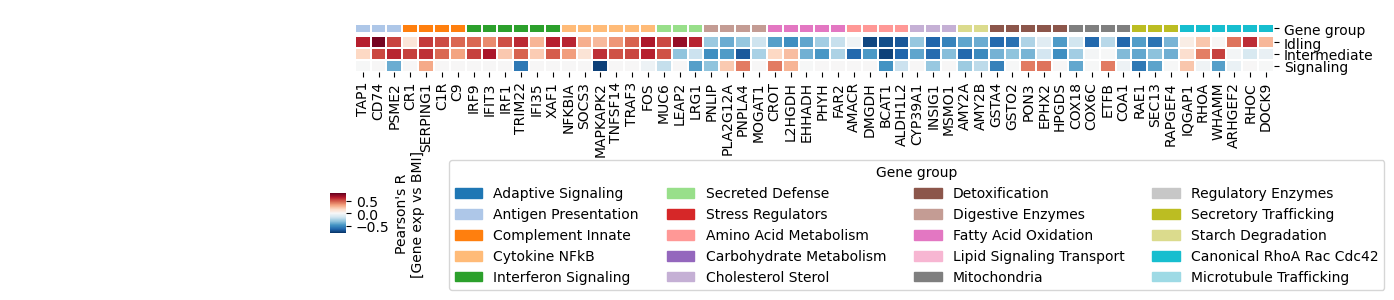

In [ ]:
import matplotlib.patches as mpatches
###-------------------------------plot-------------------------------###

# 1) Build the matrix as rows=cell types, cols=genes (DISPLAY transpose)
#    df_Rs_wV2 is genes x celltypes
acinar_df_plot = acinar_df_Rs_rm.loc[acinar_ordered_genes].T   # shape: (cell types) x (genes)

# 2) Column color bars (because genes are now COLUMNS)
big_gene_dict = {
    "Immune": acinar_immune_gene_lists,
    "Metabolism": acinar_metabolism_gene_lists,
    "Rho_GTPases": acinar_rho_gene_lists,
}
gene_to_big, gene_to_sub = {}, {}
for bigcat, subdict in big_gene_dict.items():
    for subcat, genes in subdict.items():
        for g in genes:
            gene_to_big[g] = bigcat
            gene_to_sub[g] = subcat

# 3) Series aligned to gene columns
# col_big = pd.Series([gene_to_big.get(g, "Other") for g in acinar_df_plot.columns],
#                     index=acinar_df_plot.columns)
col_sub = pd.Series([gene_to_sub.get(g, "Other") for g in acinar_df_plot.columns],
                    index=acinar_df_plot.columns)

palette_big = {
    "Immune": "#e41a1c",
    "Metabolism": "#377eb8",
    "Rho_GTPases": "#4daf4a",
#     "Other": "lightgray",
}
# unique_subs = col_sub.unique()

col_colors = pd.DataFrame({
#     "Big Category": col_big.map(palette_big),
    "Gene group":  col_sub.map(palette_sub),
})

# 4) Plot (columns=genes), keep cell-type rows uncluttered
g = sns.clustermap(
    acinar_df_plot,
    row_cluster=False,             # or True if you want to cluster cell types
    col_cluster=False,             # we already ordered genes
    cmap="RdBu_r", center=0, vmin=-0.8, vmax=0.8,
    col_colors=col_colors,         # <-- column color bars now
    linewidths=0.3,
    figsize=(16, 0.8),               # wider than tall
    colors_ratio=(.05, 0.16),       # second value widens column color bars
    cbar_kws={"label": "Pearson's R\n[Gene exp vs BMI]"},
)

g.fig.subplots_adjust(left=0.18, right=0.97, bottom=0.22, top=1)
g.cax.set_position([0.38, -1.8, .01, .5])  # [left, bottom, width, height] in figure coordinates

# 5) Make room for x (gene) labels and keep row labels readable
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, ha="center")
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0, ha="left")

# 6) Optional: custom row (cell-type) labels
g.ax_heatmap.set_ylabel("")
g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_yticks([0.5, 1.5, 2.5])
g.ax_heatmap.set_yticklabels(['Idling', 'Intermediate', 'Signaling'])

# 7) Two separate legends (big & sub), placed under/left using figure transform
# big_patches = [mpatches.Patch(color=c, label=lab.replace('_', ' '))
#                for lab, c in palette_big.items()]
sub_patches = [mpatches.Patch(color=c, label=lab.replace('_', ' '))
               for lab, c in palette_sub.items()]

# leg1 = g.ax_col_dendrogram.legend(
#     handles=big_patches, title="Big category",
#     loc="upper left", bbox_to_anchor=(0.43, -0.2),
#     bbox_transform=g.fig.transFigure,
#     frameon=True,
# )
leg2 = g.ax_col_dendrogram.legend(
    handles=sub_patches, title="Gene group",
    loc="upper left", bbox_to_anchor=(0.45, -0.8),
    bbox_transform=g.fig.transFigure,
    frameon=True,  ncol=4
)
# g.ax_col_dendrogram.add_artist(leg1)  # keep both

g.savefig(
    f'../../figures/manuscript_figures/lean_obese_f/Acinar_immune_meta_rho_pearson_r_vs_BMI_rm_3csts.png',
    bbox_inches='tight', dpi=300
           )
g.savefig(
    f'../../figures/manuscript_figures/lean_obese_f/Acinar_immune_meta_rho_pearson_r_vs_BMI_rm_3csts.pdf',
    bbox_inches='tight', dpi=300
           )

/tmp/ipykernel_4697/1969376077.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap)
/tmp/ipykernel_4697/1969376077.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


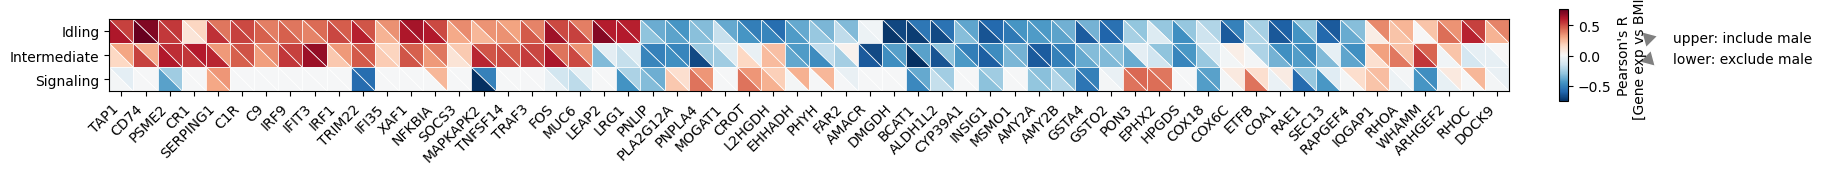

In [ ]:
fig = plot_split_heatmap(acinar_df_Rs_rF1.loc[acinar_ordered_genes], 
                         acinar_df_Rs_rm.loc[acinar_ordered_genes], 
                         exclude_sample='male',
                         transpose=True)['fig']

fig.savefig(
    f'../../figures/manuscript_figures/lean_obese_f/Acinar_immune_meta_rho_pearson_r_vs_BMI_rF1_rm_3csts.png',
    bbox_inches='tight', dpi=300
           )
fig.savefig(
    f'../../figures/manuscript_figures/lean_obese_f/Acinar_immune_meta_rho_pearson_r_vs_BMI_rF1_rm_3csts.pdf',
    bbox_inches='tight', dpi=300
           )

In [ ]:
###-------------------------------get acinar genes-------------------------------###
# combine these genes and show the pearson R's in cell type and cell subtypes
ductal_gene_lists = {
    cat: genes
    for gene_lists in [ductal_immune_gene_lists, ductal_metabolism_gene_lists, ductal_rho_gene_lists]
    for cat, genes in gene_lists.items()
}

ductal_unique_genes = list(
    set([g for gl in ductal_gene_lists.values() for g in gl])
)

cts_show = [
#     'Acinar', 'Basal_acinar', 'High_enzyme_acinar',
#     'Ductal', 
    'Basal_ductal', 'Inflam_ductal_1', 'Inflam_ductal_2', 'MUC5B+_ductal'
          ]

ductal_df_Rs_wF1 = pd.DataFrame(index=ductal_unique_genes, columns=cts_show)
for ct in cts_show:
    ductal_df_Rs_wF1[ct] = pearsonr_dic['wV2', ct].loc[ductal_unique_genes]['r']
ductal_df_Rs_wF1 = ductal_df_Rs_wF1.fillna(0)

ductal_df_Rs_rF1 = pd.DataFrame(index=ductal_unique_genes, columns=cts_show)
for ct in cts_show:
    ductal_df_Rs_rF1[ct] = pearsonr_dic['rF1', ct].loc[ductal_unique_genes]['r']
ductal_df_Rs_rF1 = ductal_df_Rs_rF1.fillna(0)

ductal_df_Rs_rF1_rV2 = pd.DataFrame(index=ductal_unique_genes, columns=cts_show)
for ct in cts_show:
    ductal_df_Rs_rF1_rV2[ct] = pearsonr_dic['rF1_rV2', ct].loc[ductal_unique_genes]['r']
ductal_df_Rs_rF1_rV2 = ductal_df_Rs_rF1_rV2.fillna(0)

ductal_df_Rs_rm = pd.DataFrame(index=ductal_unique_genes, columns=cts_show)
for ct in cts_show:
    ductal_df_Rs_rm[ct] = pearsonr_dic['rm', ct].loc[ductal_unique_genes]['r']
ductal_df_Rs_rm = ductal_df_Rs_rm.fillna(0)

###-------------------------------plot-------------------------------###
# 0) Order genes (same as before)
ductal_ordered_genes = order_genes_by_hclust_per_category(
    ductal_df_Rs_rm,                # genes x cell types
    ductal_gene_lists,        # or ductal_metabolism_gene_lists / ductal_immune_gene_lists
    metric="correlation",
    method="average",
)

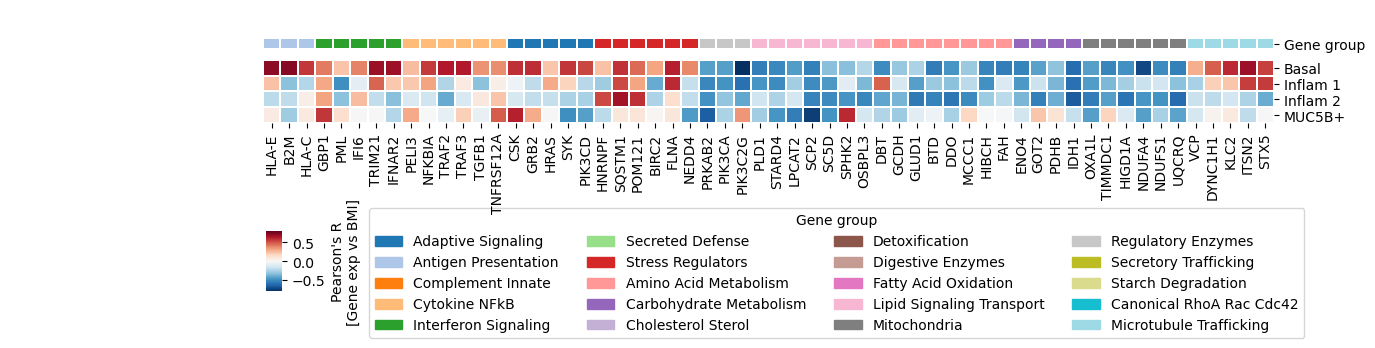

In [ ]:
# 1) Build the matrix as rows=cell types, cols=genes (DISPLAY transpose)
#    df_Rs_wV2 is genes x celltypes
ductal_df_plot = ductal_df_Rs_rm.loc[ductal_ordered_genes].T   # shape: (cell types) x (genes)

# 2) Column color bars (because genes are now COLUMNS)
big_gene_dict = {
    "Immune": ductal_immune_gene_lists,
    "Metabolism": ductal_metabolism_gene_lists,
    "Rho_GTPases": ductal_rho_gene_lists,
}
gene_to_big, gene_to_sub = {}, {}
for bigcat, subdict in big_gene_dict.items():
    for subcat, genes in subdict.items():
        for g in genes:
            gene_to_big[g] = bigcat
            gene_to_sub[g] = subcat

# 3) Series aligned to gene columns
# col_big = pd.Series([gene_to_big.get(g, "Other") for g in ductal_df_plot.columns],
#                     index=df_plot.columns)
col_sub = pd.Series([gene_to_sub.get(g, "Other") for g in ductal_df_plot.columns],
                    index=ductal_df_plot.columns)

# palette_big = {
#     "Immune": "#e41a1c",
#     "Metabolism": "#377eb8",
#     "Rho_GTPases": "#4daf4a",
# #     "Other": "lightgray",
# }
# unique_subs = col_sub.unique()
# palette_sub = dict(zip(unique_subs, sns.color_palette("tab20", len(unique_subs))))

col_colors = pd.DataFrame({
#     "Big Category": col_big.map(palette_big),
    "Gene group":  col_sub.map(palette_sub),
})

# 4) Plot (columns=genes), keep cell-type rows uncluttered
g = sns.clustermap(
    ductal_df_plot,
    row_cluster=False,             # or True if you want to cluster cell types
    col_cluster=False,             # we already ordered genes
    cmap="RdBu_r", center=0, vmin=-0.8, vmax=0.8,
    col_colors=col_colors,         # <-- column color bars now
    linewidths=0.3,
    figsize=(16, 1.5),               # wider than tall
    colors_ratio=(.05, .12),       # second value widens column color bars
    cbar_kws={"label": "Pearson's R\n[Gene exp vs BMI]"},
)

g.fig.subplots_adjust(left=0.18, right=0.97, bottom=0.22, top=0.98)
g.cax.set_position([0.34, -0.9, .01, .4])  # [left, bottom, width, height] in figure coordinates

# 5) Make room for x (gene) labels and keep row labels readable
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, ha="center")
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0, ha="left")

# 6) Optional: custom row (cell-type) labels
g.ax_heatmap.set_ylabel("")
g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_yticks([0.5, 1.5, 2.5, 3.5])
g.ax_heatmap.set_yticklabels(['Basal', 'Inflam 1', 'Inflam 2', 'MUC5B+'])

# 7) Two separate legends (big & sub), placed under/left using figure transform
# big_patches = [mpatches.Patch(color=c, label=lab.replace('_', ' '))
#                for lab, c in palette_big.items()]
sub_patches = [mpatches.Patch(color=c, label=lab.replace('_', ' '))
               for lab, c in palette_sub.items()]

# leg1 = g.ax_col_dendrogram.legend(
#     handles=big_patches, title="Big category",
#     loc="upper left", bbox_to_anchor=(0.43, -0.2),
#     bbox_transform=g.fig.transFigure,
#     frameon=True,
# )
leg2 = g.ax_col_dendrogram.legend(
    handles=sub_patches, title="Gene group",
    loc="upper left", bbox_to_anchor=(0.4, -0.3),
    bbox_transform=g.fig.transFigure,
    frameon=True,  ncol=4
)
# g.ax_col_dendrogram.add_artist(leg1)  # keep both

g.savefig(
    f'../../figures/manuscript_figures/lean_obese_f/Ductal_immune_meta_rho_pearson_r_vs_BMI_rm.png',
    bbox_inches='tight', dpi=300
           )
g.savefig(
    f'../../figures/manuscript_figures/lean_obese_f/Ductal_immune_meta_rho_pearson_r_vs_BMI_rm.pdf',
    bbox_inches='tight', dpi=300
           )

/tmp/ipykernel_4697/1969376077.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap)
/tmp/ipykernel_4697/1969376077.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


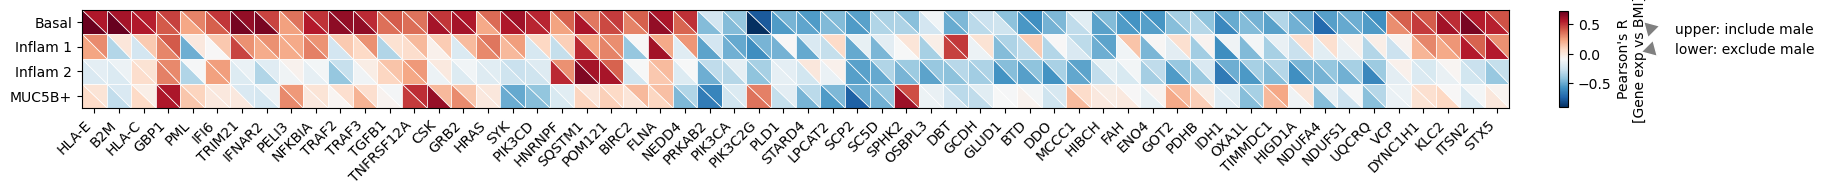

In [ ]:
fig = plot_split_heatmap(ductal_df_Rs_rF1.loc[ductal_ordered_genes], 
                         ductal_df_Rs_rm.loc[ductal_ordered_genes], 
                         exclude_sample='male',
                         transpose=True)['fig']

fig.savefig(
    f'../../figures/manuscript_figures/lean_obese_f/Ductal_immune_meta_rho_pearson_r_vs_BMI_rF1_rm_3csts.png',
    bbox_inches='tight', dpi=300
           )
fig.savefig(
    f'../../figures/manuscript_figures/lean_obese_f/Ductal_immune_meta_rho_pearson_r_vs_BMI_rF1_rm_3csts.pdf',
    bbox_inches='tight', dpi=300
           )